## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up session

Instantiate a `Session` with a `name` and `data_path` to the folder with input data. Next add scenarios to run with `.add_scenario()`, in this case we only use default data by setting `scenario` to `None`

In [3]:
# Create session
session = cm.Session(
    name = 'base_year',
    data_path = '../data'
)

# Add scenarios
session.add_scenario(
    name = 'base year',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.2)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.6)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.8)',
    scenario_workbooks = None,
    years = '2020'
)

A scenario with the name 'base year' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.2)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.6)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.8)' already exists use .update_scenario() or .remove_scenario() instead.


## Instantiate modules and run model

In [4]:
%%time
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

CPU times: total: 5.98 s
Wall time: 6.15 s


In [ ]:
%%time
# Set to true to print progress messages
msg = True
scale_powers = {
    'base year' : 0.4,
    'base year (sp=0.2)' : 0.2,
    'base year (sp=0.6)' : 0.6,
    'base year (sp=0.8)' : 0.8,
}

# Loop through scenarios and years
for scn, year in session.iterate('all'):
    print(scn,year)
    # Reload parameter data
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year=year
    )

    # Get region attributes
    regions.calculate(verbose=msg)

    # Calculate food demand
    demand.calculate(verbose=msg)

    # Calculate crops
    crops.calculate(
        verbose=msg
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=scale_powers[scn], verbose=msg)
    # Solve optimisation problem (move to next scn/year if it fails)
    try:
        geodist.solve(verbose=msg, apply_solution=False)
    except Exception as e:
        print(f'(!!!) GeoDistributor failed for {scn}, {year} with {type(e).__name__}: {e}')
        continue

    # Set crop areas to x0 areas (for validation)
    # geodist.x['crp'] = geodist.x0['crp']

    # Apply solution
    geodist.apply_solution()
        
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)

    # Calculate manure
    manure_mgmt.calculate(verbose=msg)

    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)

    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)

    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)

    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)

    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds, waste, geodist
    )

In [ ]:
session

# Check solution

In [7]:
scn = 'base year'
year = '2020'

bar_style = {
    'kind' : 'bar',
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlGnBu',
    'edgecolor' : 'grey'
}

### Animal product demand compared to statistics

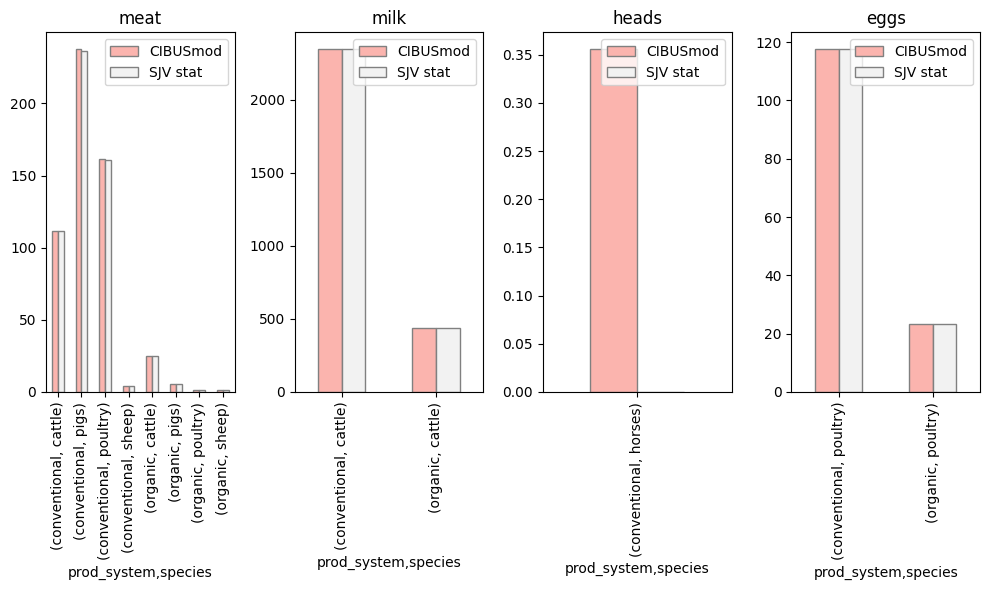

In [8]:
# SJV statistics 2016-2020
# 1000 tonnes
tot_milk = (2862.23+2816.66+2760.23+2704.39+2772.74)/5
org_milk = (369.20+414.23+464.97+464.17+481.20)/5

tot_cattle_meat = (131.25+132.07+136.87+139.67+141.00)/5
org_cattle_meat = (18887+19088+19290+21806+22382+21853)/5/1000

tot_pig_meat = (232.80+240.70+249.79+240.29+246.54)/5
org_pig_meat = (4819+4811+5540+6135+6553)/5/1000

tot_sheep_meat = (5.04+5.26+5.60+5.09+4.86)/5
org_sheep_meat = (1138+1109+1187+1063+993)/5/1000

tot_poultry_meat = (158.03+158.78+156.75+165.22+172.28)/5 # Summa fjäderfä, exkl kasserade
tot_poultry_meat2 = (148.49+148.54+146.28+155.18+162.06)/5 # Slaktkyckling, exkl kasserade
org_poultry_meat2 = (1523+1667+1217+1333+1420)/5/1000 # Slaktkyckling
org_poultry_meat = org_poultry_meat2 * tot_poultry_meat/tot_poultry_meat2

tot_eggs = (120.71*1.135 + 118.19*1.14 + 122.79*1.13 + 130.30*1.13 + 129.74*1.13)/5 
org_eggs = (21.35*1.135 + 20.38*1.14 + 20.54*1.13 + 20.46*1.13 + 20.45*1.13)/5

stat = pd.Series(
    {
        ('conventional','cattle','meat')    : tot_cattle_meat-org_cattle_meat,
        ('organic','cattle','meat')         : org_cattle_meat,
        ('conventional','cattle','milk')    : tot_milk-org_milk,
        ('organic','cattle','milk')         : org_milk,
        ('conventional','pigs','meat')      : tot_pig_meat-org_pig_meat,
        ('organic','pigs','meat')           : org_pig_meat,
        ('conventional','sheep','meat')     : tot_sheep_meat-org_sheep_meat,
        ('organic','sheep','meat')          : org_sheep_meat,
        ('conventional','poultry','meat')   : tot_poultry_meat-org_poultry_meat,
        ('organic','poultry','meat')        : org_poultry_meat,
        ('conventional','poultry','eggs')   : tot_eggs-org_eggs,
        ('organic','poultry','eggs')        : org_eggs
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

plot_data = pd.concat([
    session.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).loc[(scn,year)].rename('CIBUSmod')/1000000,
    stat.rename('SJV stat')
], axis=1)

aps = plot_data.index.get_level_values('animal_prod').unique()
fig, axs = fig, axs = plt.subplots(1,len(aps), figsize=(10,6))

i=0
for ap in aps:
    ax = axs[i]
    plot_data.xs(ap,level='animal_prod').plot(**bar_style, ax=ax)
    ax.set_title(ap)
    i+=1
    
plt.tight_layout()
plt.show()

### Manure excretion

#### Volatile solids

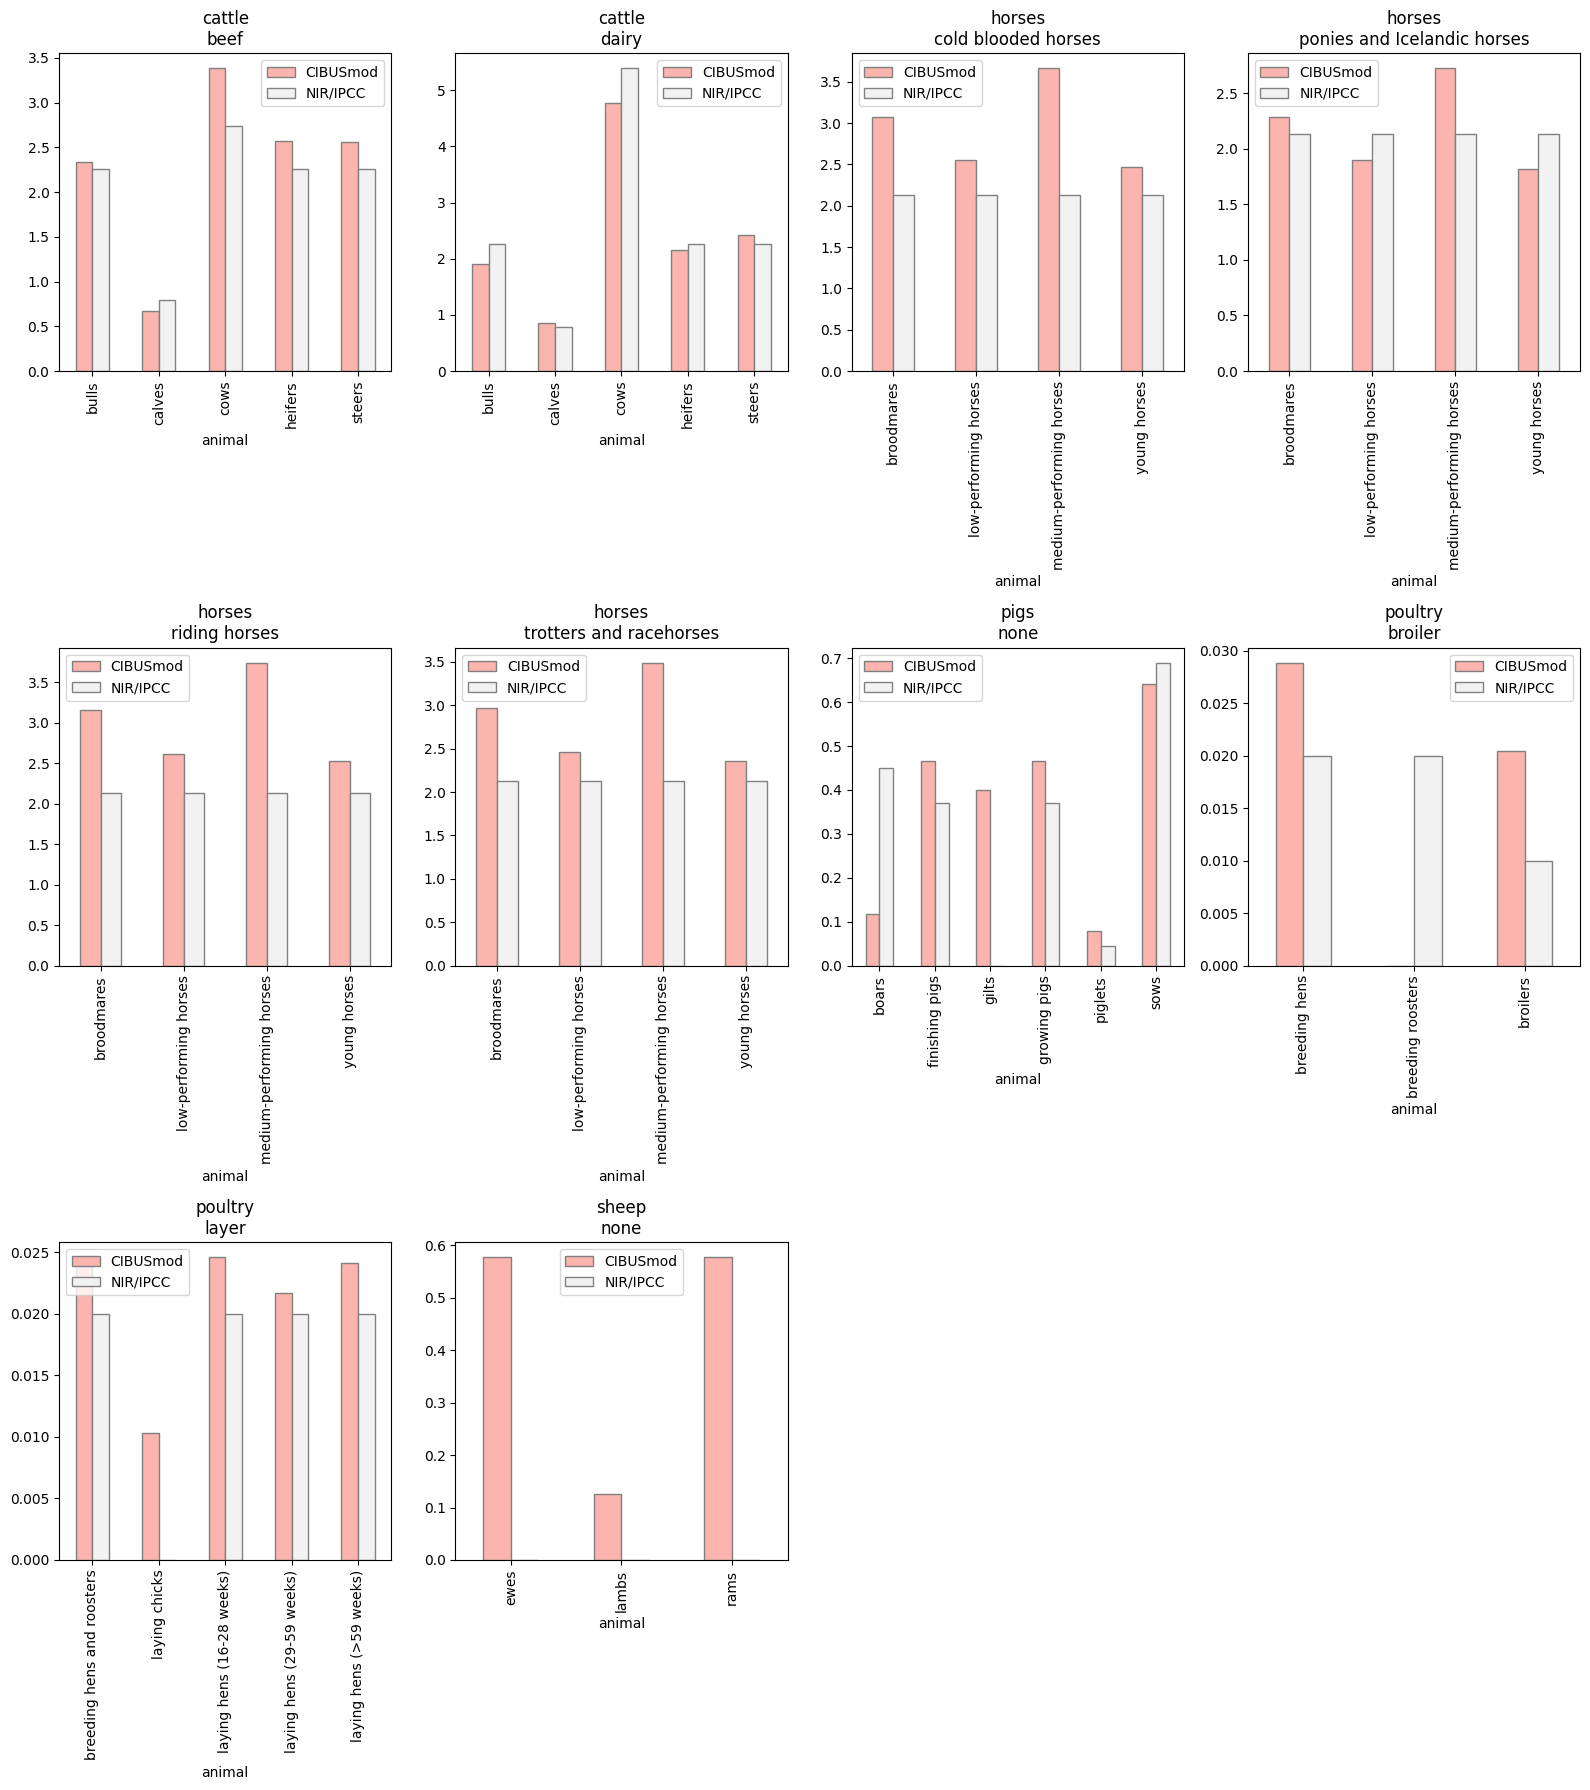

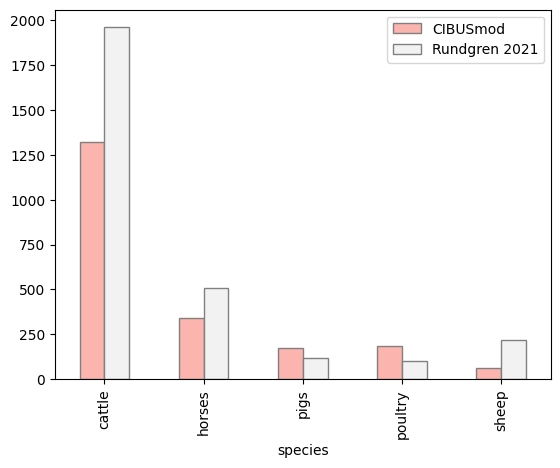

In [9]:
VS_per_head = (
    session.get_attr('A','manure.VS_excr',['species','breed','animal']) / 
    session.get_attr('A','heads',['species','breed','animal']) /
    365.25
).loc[(scn,year)].rename('CIBUSmod')

NIR_IPCC = pd.Series({
    ('cattle','dairy','cows'):5.39,
    ('cattle','dairy','calves'):0.79,
    ('cattle','dairy','heifers'):2.26,
    ('cattle','dairy','steers'):2.26,
    ('cattle','dairy','bulls'):2.26,
    ('cattle','beef','cows'):2.74, # Avg. grazing / stable
    ('cattle','beef','calves'):0.79,
    ('cattle','beef','heifers'):2.26,
    ('cattle','beef','steers'):2.26,
    ('cattle','beef','bulls'):2.26,
    ('horses','cold blooded horses','broodmares') : 2.13,
    ('horses','cold blooded horses','low-performing horses') : 2.13,
    ('horses','cold blooded horses','medium-performing horses') : 2.13,
    ('horses','cold blooded horses','young horses') : 2.13,
    ('horses','ponies and Icelandic horses','broodmares') : 2.13,
    ('horses','ponies and Icelandic horses','low-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','young horses') : 2.13,
    ('horses','riding horses','broodmares') : 2.13,
    ('horses','riding horses','low-performing horses') : 2.13,
    ('horses','riding horses','medium-performing horses') : 2.13,
    ('horses','riding horses','young horses') : 2.13,
    ('horses','trotters and racehorses','broodmares') : 2.13,
    ('horses','trotters and racehorses','low-performing horses') : 2.13,
    ('horses','trotters and racehorses','medium-performing horses') : 2.13,
    ('horses','trotters and racehorses','young horses') : 2.13,
    ('pigs','none','boars') : 0.45,
    ('pigs','none','finishing pigs') : 0.37,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 0.37,
    ('pigs','none','piglets') : 0.044,
    ('pigs','none','sows') : 0.69,
    ('poultry','broiler','breeding hens') : 0.02,
    ('poultry','broiler','breeding roosters') : 0.02,
    ('poultry','broiler','broilers') : 0.01,
    ('poultry','layer','breeding hens and roosters') : 0.02,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.02,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.02,
    ('poultry','layer','laying hens (>59 weeks)') : 0.02,
}).rename('NIR/IPCC')
NIR_IPCC.index.names = VS_per_head.index.names

plot_data = pd.concat([
    VS_per_head,
    NIR_IPCC
], axis=1)

fig,axs = plot.subplots(plot_data, ['species','breed'], **bar_style, size=(4,6))
plt.tight_layout()
plt.show()

# Compared to Rundgren 2021
plot_data = pd.concat([
    session.get_attr('A','manure.VS_excr','species').loc[(scn,year)].rename('CIBUSmod')/1000000,
    pd.Series(
        [1960,510,217,119,60+39],
        index=pd.Index(['cattle','horses','sheep','pigs','poultry'], name='species'),
        name='Rundgren 2021'
    )
], axis=1)

plot_data.plot(**bar_style)
plt.show()

#### Nitrogen

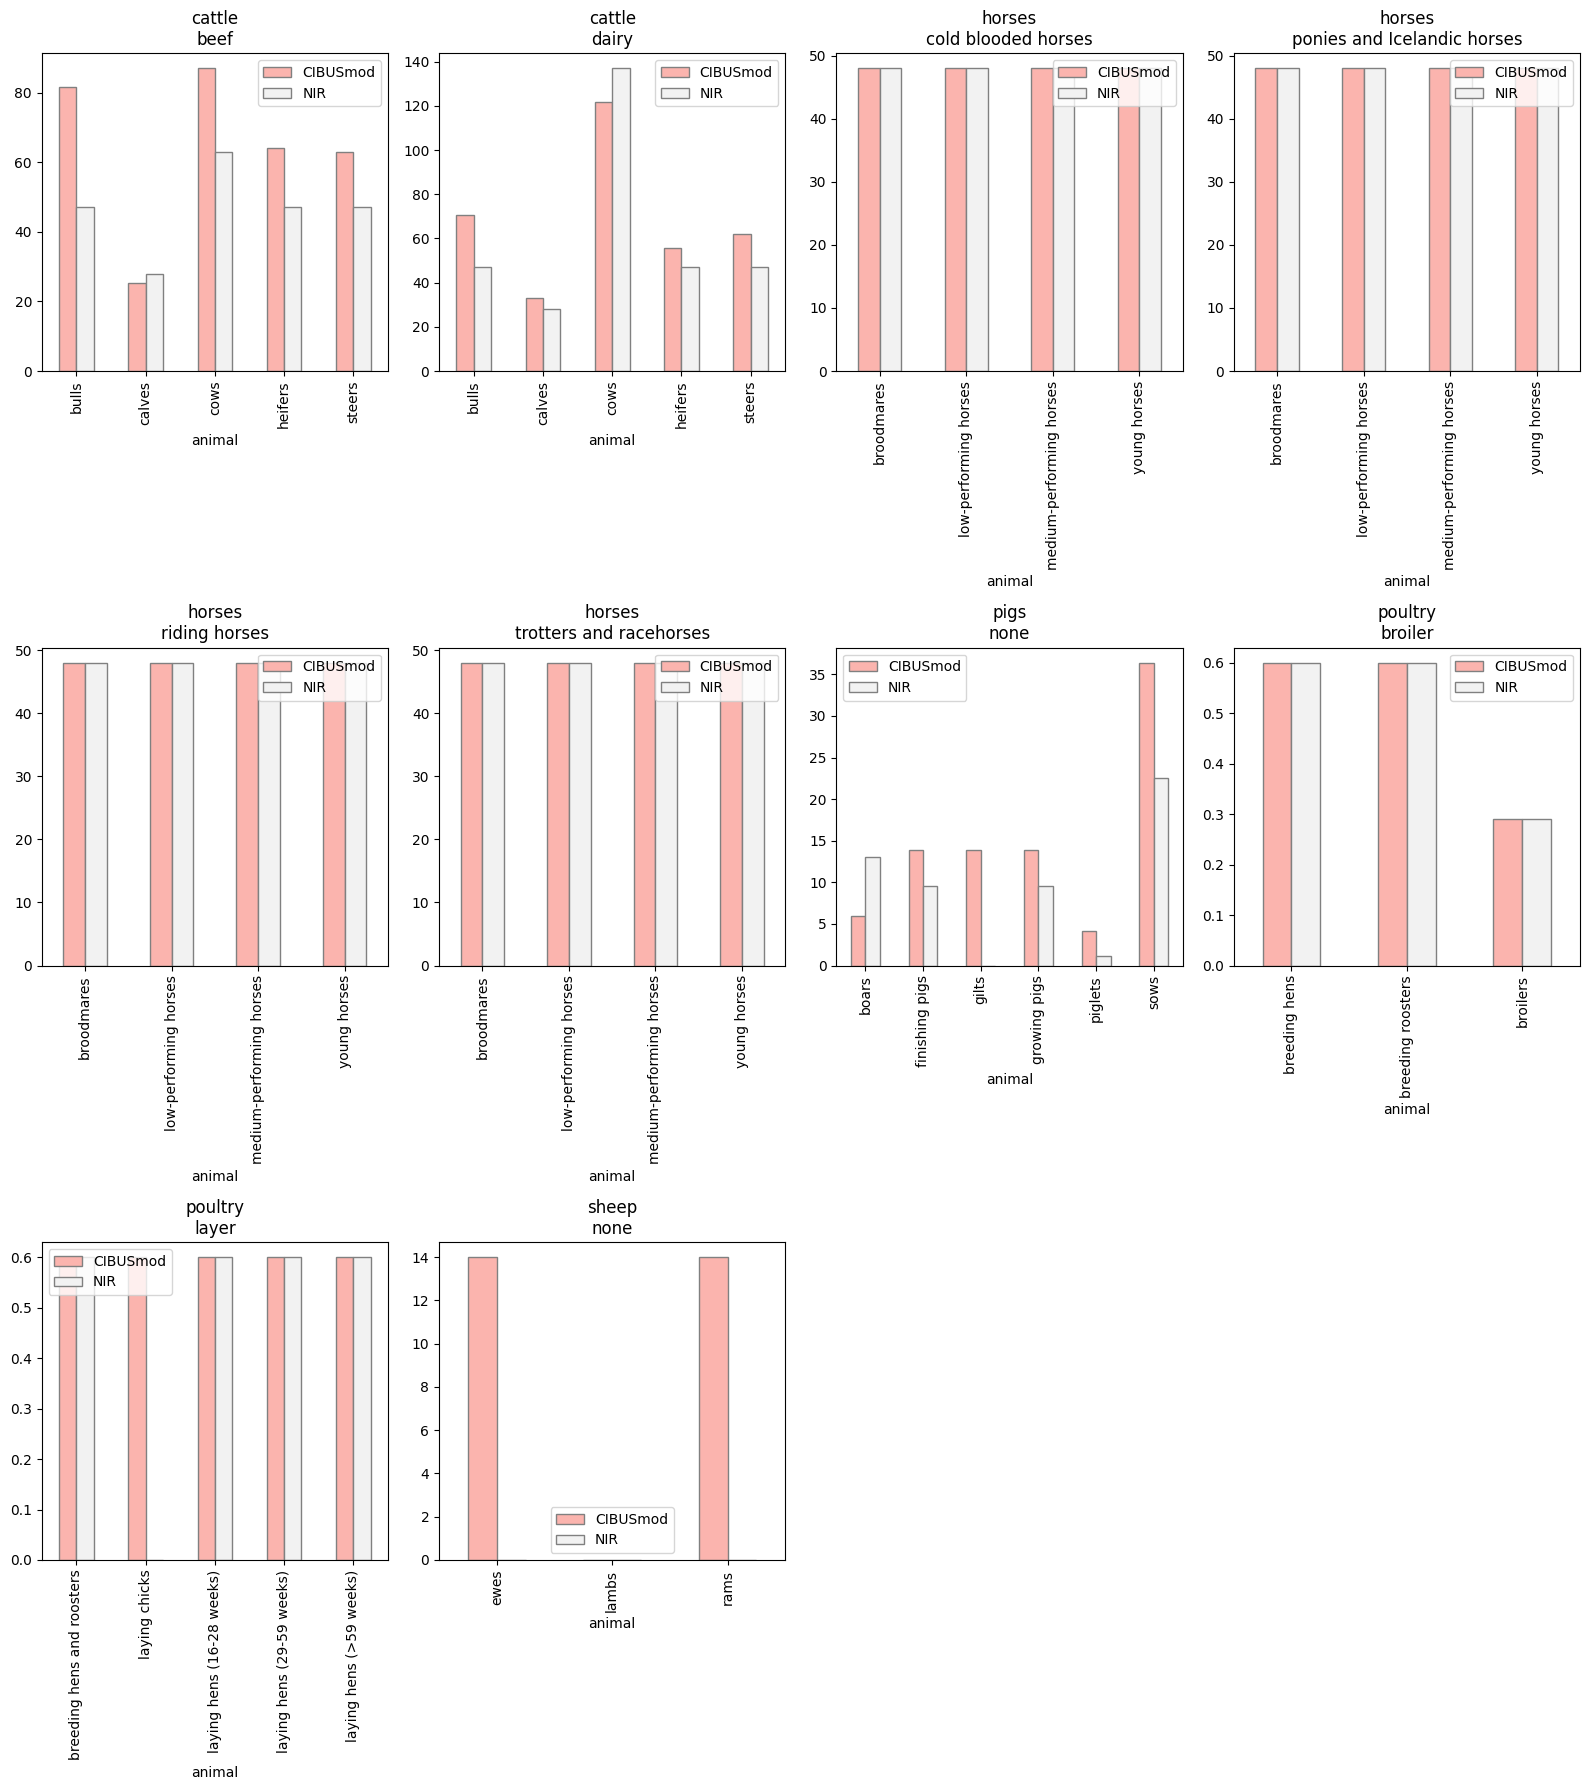

In [10]:
N_per_head = (
    session.get_attr('A','manure.N_excr',['species','breed','animal']) / 
    session.get_attr('A','heads',['species','breed','animal'])
).loc[(scn,year)].rename('CIBUSmod')

NIR = pd.Series({
    ('cattle','dairy','cows'):137,
    ('cattle','dairy','calves'):28,
    ('cattle','dairy','heifers'):47,
    ('cattle','dairy','steers'):47,
    ('cattle','dairy','bulls'):47,
    ('cattle','beef','cows'):63,
    ('cattle','beef','calves'):28,
    ('cattle','beef','heifers'):47,
    ('cattle','beef','steers'):47,
    ('cattle','beef','bulls'):47,
    ('horses','cold blooded horses','broodmares') : 48,
    ('horses','cold blooded horses','low-performing horses') : 48,
    ('horses','cold blooded horses','medium-performing horses') : 48,
    ('horses','cold blooded horses','young horses') : 48,
    ('horses','ponies and Icelandic horses','broodmares') : 48,
    ('horses','ponies and Icelandic horses','low-performing horses') : 48,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 48,
    ('horses','ponies and Icelandic horses','young horses') : 48,
    ('horses','riding horses','broodmares') : 48,
    ('horses','riding horses','low-performing horses') : 48,
    ('horses','riding horses','medium-performing horses') : 48,
    ('horses','riding horses','young horses') : 48,
    ('horses','trotters and racehorses','broodmares') : 48,
    ('horses','trotters and racehorses','low-performing horses') : 48,
    ('horses','trotters and racehorses','medium-performing horses') : 48,
    ('horses','trotters and racehorses','young horses') : 48,
    ('pigs','none','boars') : 13,
    ('pigs','none','finishing pigs') : 9.5,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 9.5,
    ('pigs','none','piglets') : 1.2,
    ('pigs','none','sows') : 22.5,
    ('poultry','broiler','breeding hens') : 0.6,
    ('poultry','broiler','breeding roosters') : 0.6,
    ('poultry','broiler','broilers') : 0.29,
    ('poultry','layer','breeding hens and roosters') : 0.6,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.6,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.6,
    ('poultry','layer','laying hens (>59 weeks)') : 0.6,
}).rename('NIR')
NIR.index.names = N_per_head.index.names

plot_data = pd.concat([
    N_per_head,
    NIR
], axis=1)

fig,axs = plot.subplots(plot_data,['species','breed'],**bar_style,size=(4,6))
plt.tight_layout()
plt.show()

### GHG emissions compared to NIR

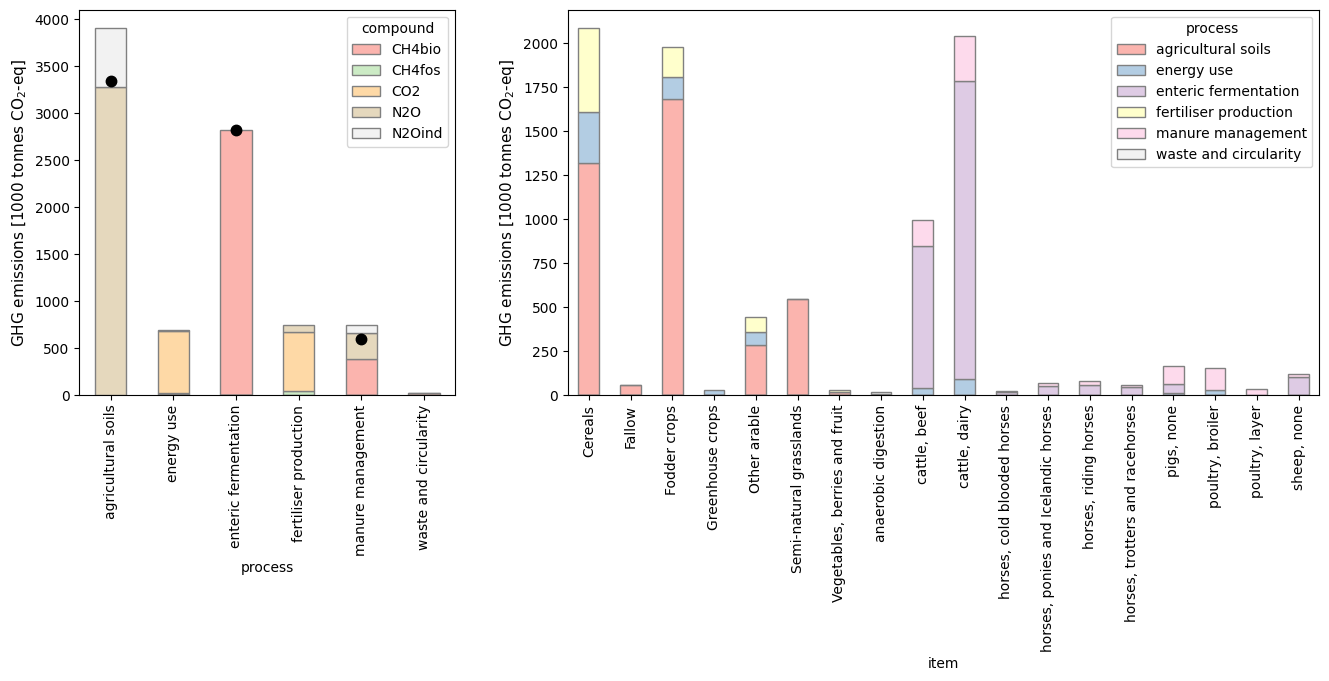

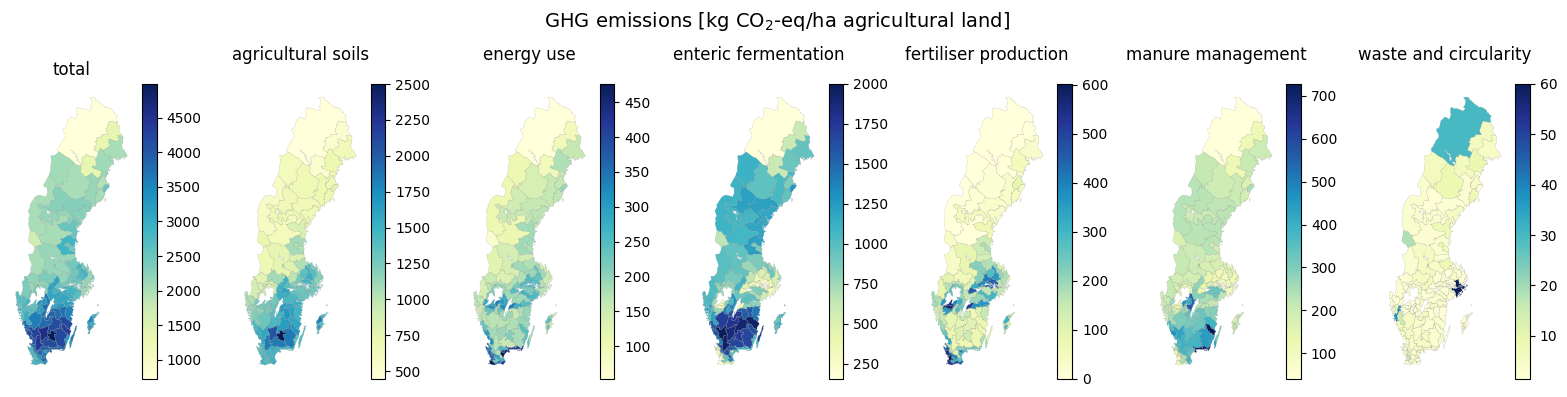

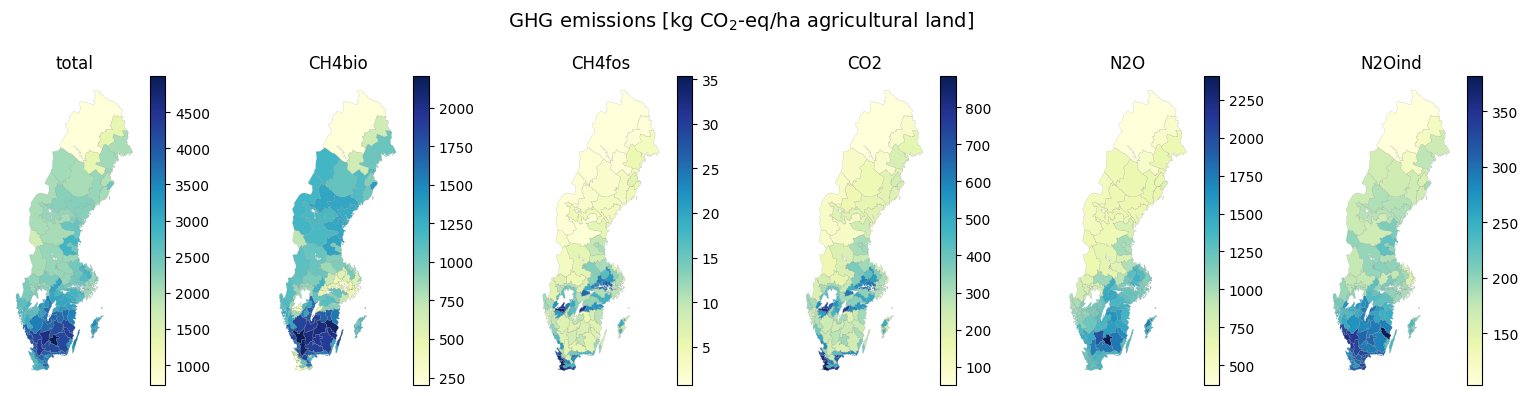

In [11]:
# Bar plot [1000 tonnes CO2eq] ----->

GHG_data = cm.get_GHG(session, scn='base year')

fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
# Avg. 2016-2020 https://www.naturvardsverket.se/data-och-statistik/klimat/vaxthusgaser-utslapp-fran-jordbruk/
plot_data_NIR = pd.Series(
    [3341.2,np.nan,2820.8,np.nan,590.8,np.nan]
)

ax=axs[0]
plot_data_NIR.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
plot_data.plot(**bar_style, stacked='True', ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot(**bar_style, stacked='True', ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plt.show()

# Maps [kg CO2eq/ha] ----->
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year)].drop('greenhouse')
    .groupby('region').sum()
)

# per process
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','process'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_proc = len(plot_data.columns)

fig, axs = plt.subplots(1,n_proc+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], **map_style, ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

# per GHG
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','compound'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_ghg = len(plot_data.columns)

fig, axs = plt.subplots(1,n_ghg+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for cp in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[cp], **map_style, ax=ax)
    ax.set_title(cp)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

### Nitrogen in manure and fertiliser

In [12]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga areas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total for sweden (SCB, Gödselemedl i jordbruket)
# Avg. 2015/2016, 2018/2019 and 2021/2022
stat_N_total = pd.Series({ # [1000 tonnes N/P/K]
    ('N','mineral') : (165+180+164)/3,
    ('N','manure')  : (77+77+81)/3,
    ('N','organic') : (3590+4370)/2/1000/0.4, # Tablå 3, avg 2018/19 and 2021/22, assuming 40% of N plant available
    ('P','mineral') : (12.49+13.72+12.97)/3,
    ('P','manure')  : (29.37+30.8+30.41)/3 - (12.49+13.72+12.97)/3,
    ('P','organic') : (820+910)/2/1000, # Tablå 3, avg 2018/19 and 2021/22
    ('K','mineral') : (28.72+29.84+27.8)/3,
    ('K','manure')  : (118.1+122.2+121.36)/3 - (28.72+29.84+27.8)/3,
    ('K','organic') : (2960+3110)/2/1000 # Tablå 3, avg 2018/19 and 2021/22
})
stat_N_crop_tot = pd.Series([ # [1000 tonnes N]
    np.nan, # Not incl
    (1.7+1.0 + 1.9+1.2 + 1.3+1.0)/3, # Ley grazing
    (23+12 + 24+11 + 28+12)/3, # Other
    (35+39 + 46+42 + 31+43)/3, # Ley fodder
    (105+25 + 108+23 + 104+24)/3, # Cereals
])
stat_N_crop_per_ha = pd.Series([ # [kg N/ha]
    np.nan, # Not incl
    ((42+25)*42 + (41+26)*46 + (38+29)*34) / (42+46+34 + 150+148+148), # Ley grazing
    ((97+50)*236 + (95+43)*257 + (99+44)*281) / (236+257+281 + 133+108+119), # Other
    ((62+68)*567 + (71+65)*644 + (55+75)*571) / (567+644+571 + 248+209+245), # Ley fodder
    ((107+25)*983 + (113+24)*962 + (112+26)*928) / (983+962+928 + 36+31+35), # Cereals
])

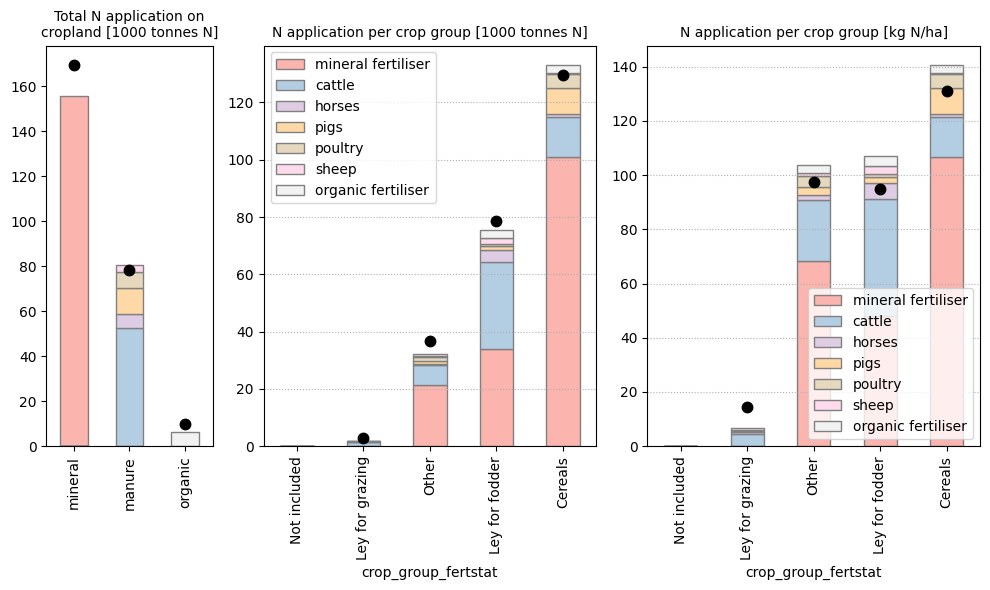

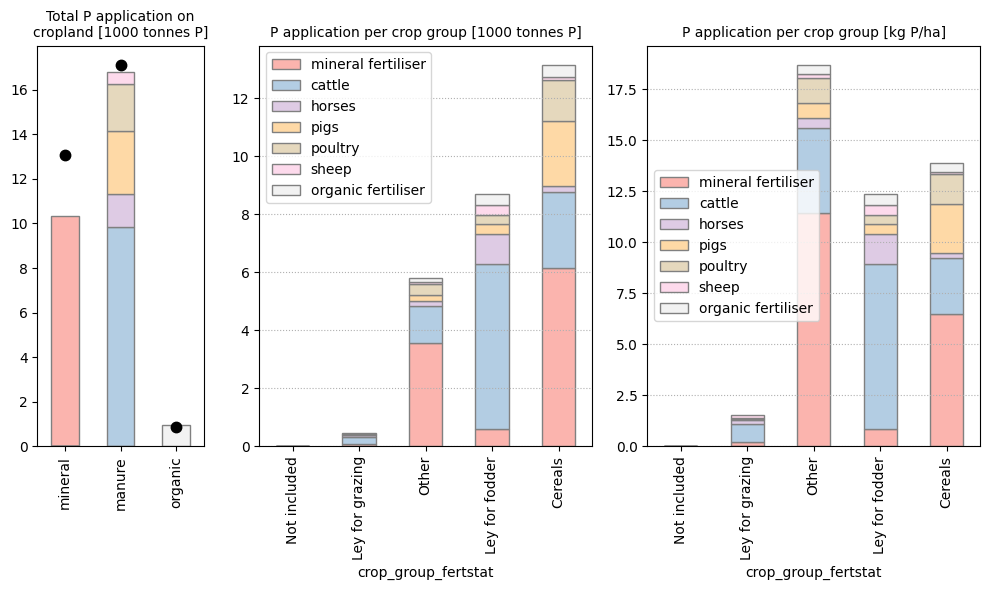

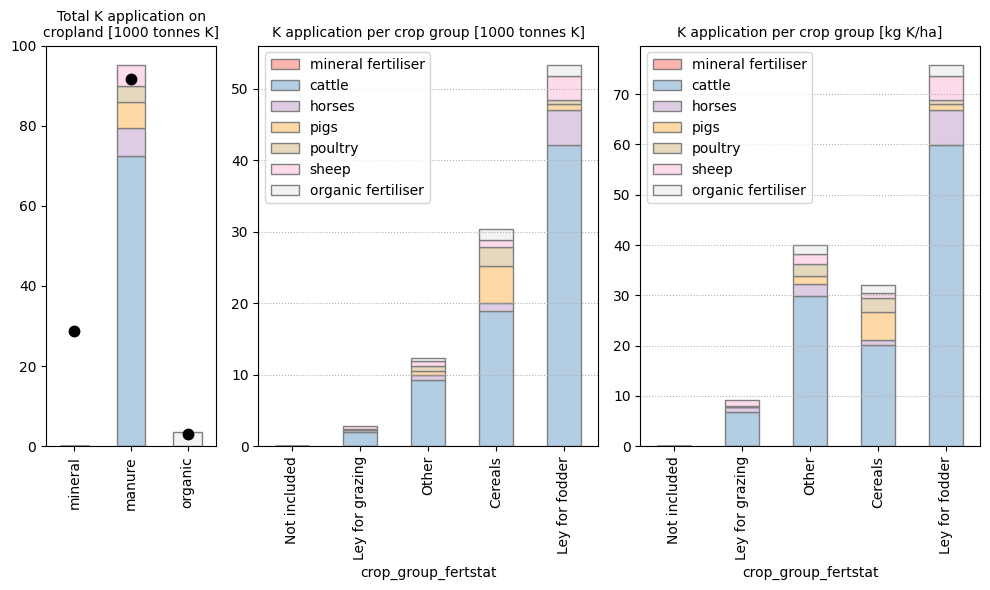

In [13]:
for element in ['N','P','K']:
    area = (
        session.get_attr(
            'C',
            'area',
            {'crop':'crop_group_fertstat'}
        )
        .loc[(scn,year)]
    )
    mineral_fert = (
        session.get_attr(
            'C',f'fertiliser.mineral_{element}',
            {'crop':'crop_group_fertstat'}
        )
        .loc[(scn,year)]
        .rename('mineral fertiliser')
    )
    manure = (
        session.get_attr(
            'C',
            f'fertiliser.manure_{element}',
            {'crop':'crop_group_fertstat', 'species':None, 'MMS':None}
        )
        .loc[(scn,year)]
        .unstack('species')
        .drop('grazing', level='MMS')
        .groupby('crop_group_fertstat')
        .sum()
    )
    organic_fert = (
        session.get_attr(
            'C',f'fertiliser.organic_{element}',
            {'crop':'crop_group_fertstat'}
        )
        .loc[(scn,year)]
        .rename('organic fertiliser')
    )
    
    plot_data = pd.concat([mineral_fert, manure, organic_fert], axis=1)/1000000
    plot_data = plot_data.reindex(set(plot_data.index.to_list()+['Not included']), fill_value=0)
    plot_data_tot = plot_data.sum().rename('mineral fertiliser').to_frame()
    plot_data_tot['manure'] = plot_data_tot['mineral fertiliser'] * [0 if i in ['mineral fertiliser','organic fertiliser'] else 1 for i in plot_data_tot.index]
    plot_data_tot['organic fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'organic fertiliser' else 0 for i in plot_data_tot.index]
    plot_data_tot['mineral fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'mineral fertiliser' else 0 for i in plot_data_tot.index]
    
    fig, axs = plt.subplots(1,3, figsize=(10,6), gridspec_kw={'width_ratios': [1, 2, 2]})
    # Total manure and mineral fertiliser [tonnes]
    ax = axs[0]
    plot_data_tot.T.plot(**bar_style, stacked=True, ax = ax, legend=False)
    stat_N_total.loc[element].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
    ax.set_title(f'Total {element} application on\ncropland [1000 tonnes {element}]', size=10)
    
    # Manure and mineral fertiliser per crop group
    ax = axs[1]
    s = plot_data.sum(axis=1).sort_values().index
    plot_data.loc[s].plot(**bar_style, stacked=True, ax=ax)
    if element == 'N':
        stat_N_crop_tot.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
    ax.grid('on', linestyle=':', which='both', axis='y')
    ax.set_title(f'{element} application per crop group [1000 tonnes {element}]', size=10)
    
    # Manure and mineral fertiliser per crop group per area
    ax = axs[2]
    (plot_data.div(area, axis=0)*1000000).loc[s].plot(**bar_style, stacked=True, ax=ax)
    if element == 'N':
        stat_N_crop_per_ha.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
    ax.grid('on', linestyle=':', which='both', axis='y')
    ax.set_title(f'{element} application per crop group [kg {element}/ha]', size=10)
    
    plt.tight_layout()
    plt.show()

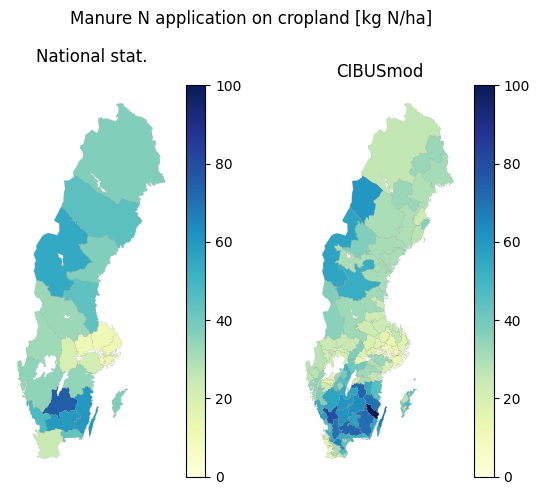

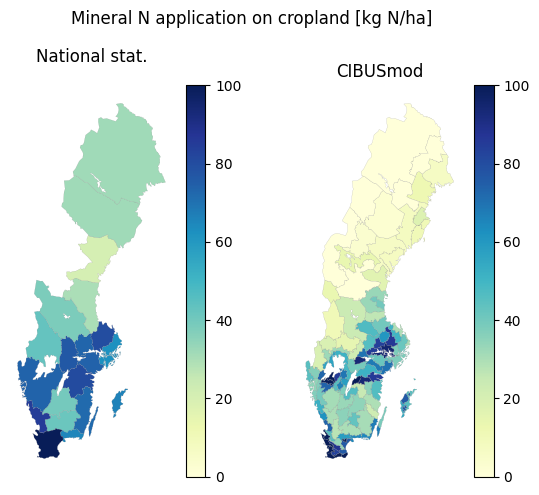

In [14]:
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year),'cropland']
)

# Manure per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['manure'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session
    .get_attr('C','fertiliser.manure_N',{'crop':'land_use', 'MMS':None, 'region':None})
    .loc[(scn,year)]
    .drop('grazing', level='MMS')
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Manure N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

# Mineral per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session
    .get_attr('C','fertiliser.mineral_N',{'crop':'land_use', 'region':None})
    .loc[(scn,year)]
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Mineral N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

### Waste treatment

In [15]:


print('2016 (alla anläggningar)')
tot_2016 = 2_018 #GWh
print('food waste:',tot_2016 * 11/100,'GWh')
print('manure:',tot_2016 * 19/100,'GWh')
print('food industry:',tot_2016 * 10/100,'GWh')

print('\n2020 (alla anläggningar)')
tot_2020 = 2_161 #GWh
print('food waste:',tot_2020 * 21/100,'GWh')
print('manure:',tot_2020 * 11/100,'GWh')
print('food industry:',tot_2020 * 7/100,'GWh')

print('\n2022 (samrötning)')
tot_2022 = 1_145 #GWh
print('food waste:',round(tot_2022 * ((426*148)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('manure:',round(tot_2022 * ((661*26)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('food industry:',round(tot_2022 * ((293*66)/(426*148+661*26+293*66+186*120+204*100))),'GWh')

print('\nCIBUSmod energy production [GWh]')
print(session.get_attr('w','energy_prod').loc[(scn,year)].groupby(['treatment','feedstock_type']).sum()/1000000)

print(
    '',
    '---------------------------',
    'Total N in feedstocks to AD',
    '---------------------------',
    sep='\n'
)
print(
    'Swe IIR 2023 Table 6-11 (avg 2016-2020):',
    round((13_139+12_934+13_880+15_119+15_017)/5),
    't N'
)
print(
    'CIBUSmod:',
    round(session.get_attr('w','feedstock_N').loc[(scn,year)].xs('anaerobic digestion', level='treatment').sum()/1000),
    't N'
)

2016 (alla anläggningar)
food waste: 221.98 GWh
manure: 383.42 GWh
food industry: 201.8 GWh

2020 (alla anläggningar)
food waste: 453.81 GWh
manure: 237.71 GWh
food industry: 151.27 GWh

2022 (samrötning)
food waste: 507 GWh
manure: 138 GWh
food industry: 156 GWh

CIBUSmod energy production [GWh]
treatment            feedstock_type        
anaerobic digestion  crop feedstock              2.271180
                     food waste, household     322.306194
                     food waste, processing     63.401565
                     food waste, retail         64.495457
                     manure                    110.776055
Name: (base year, 2020), dtype: float64

---------------------------
Total N in feedstocks to AD
---------------------------
Swe IIR 2023 Table 6-11 (avg 2016-2020): 14018 t N
CIBUSmod: 6376 t N


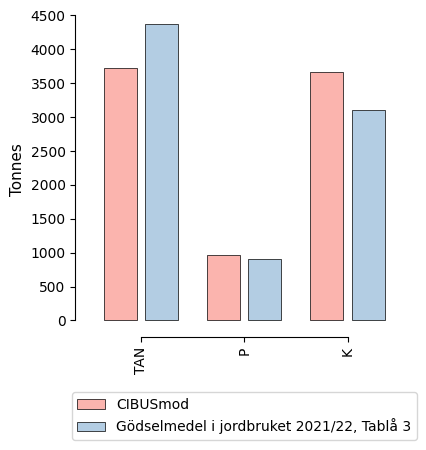

In [16]:

df_Cm = pd.concat([
    session.get_attr('w','organic_fertiliser_TAN',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_P',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_K',['treatment']).loc[(scn,year)]
]).rename('CIBUSmod')/1000
df_Cm.index = ['TAN','P','K']

# "Biogödsel totalt" according to statistics (Gödselmedel i jordbruket 2021/22, Tablå 3)
df_stat = pd.Series({
    'TAN' : 4370,
    'P' : 910,
    'K' : 3110
}).rename('Gödselmedel i jordbruket 2021/22, Tablå 3')

df = pd.concat([df_Cm,df_stat], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(df, stacked=False, cmap='Pastel1', ylabel='Tonnes', ax=ax)
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize=10)
plt.show()

### Energy use

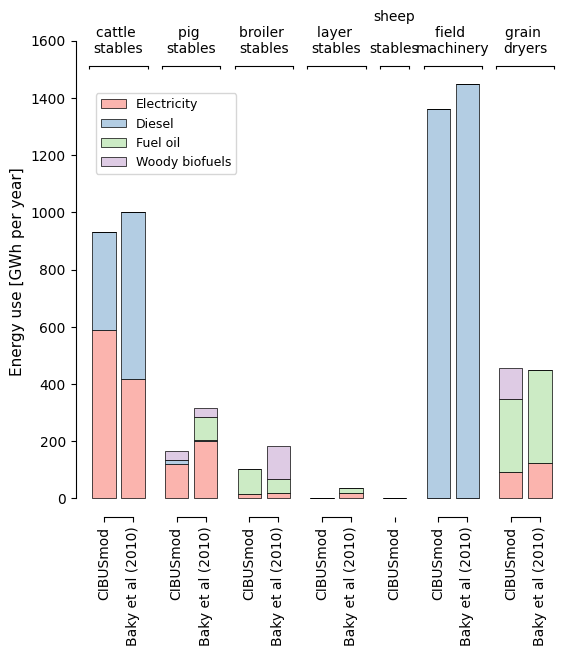

In [17]:
plot_data = (
    session.get_attr('A','energy_use',['species','breed','energy_source'])
    .loc[(scn,year)]
    .rename({'beef':'all','dairy':'all'})
    .groupby(['species','breed','energy_source'])
    .sum()
    .unstack()
    .loc[:,['Electricity','Diesel','Fuel oil','Woody biofuels']]
    /1000000
)
idx = pd.MultiIndex.from_tuples(
    [('cattle stables','CIBUSmod'),('pig stables','CIBUSmod'),
     ('broiler stables','CIBUSmod'),('layer stables','CIBUSmod'),
    ('sheep stables','CIBUSmod')],
    names=['category','source']
)
plot_data.index = idx[:3]
plot_data = plot_data.reindex(idx, fill_value=0)

plot_data.loc[('field machinery','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),'field machinery'].rename({'Biodiesel':'Diesel'})
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('grain dryers','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),['grain dryers', 'grain dryers auxiliary energy']]
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('cattle stables','Baky et al (2010)'),:]  = [  341+76,   118+466,      0,       0 ]
plot_data.loc[('pig stables','Baky et al (2010)'),:]     = [  134+66,       5+0,   79+0,    32+0 ]
plot_data.loc[('broiler stables','Baky et al (2010)'),:] = [      20,       0.6,     46,     116 ]
plot_data.loc[('layer stables','Baky et al (2010)'),:]   = [      19,       0.2,     19,       0 ]
plot_data.loc[('field machinery','Baky et al (2010)'),:] = [       0,      1449,      0,       0 ]
plot_data.loc[('grain dryers','Baky et al (2010)'),:] =    [     125,         0,      325,     0 ]

plot_data = plot_data.fillna(0)

fig, ax = plt.subplots(figsize=(6,6))
plot.bar_stacked_grouped(plot_data, ax=ax, cmap='Pastel1', ylabel='Energy use [GWh per year]', xlabel='', sort_xlabels=False)
plt.legend(bbox_to_anchor=(0, 0.9), loc='upper left', fontsize=9)
plt.show()

plot_data.sort_index().style \
.format(precision=0, thousands=" ")

### Feed rations and use of by-products

In [18]:
session.get_attr('D', 'by_products', 'by_prod')

,by_prod,apple pulp,barley brewers grain,buttermilk,cattle butcher fat,cattle offals,cattle skins,cattle slaughterhouse fat,milling by-products from oats,"milling by-products from wheat, barley or rye",pig butcher fat,...,rapeseed cake,rapeseed meal,sheep offals (by-product from live weight),sheep skins fresh (by-product from live weight),sheep slaughterhouse fat (by-product from live weight),sugar beet molasses,sugar beet pulp,wheat distillers grain,wheat gluten?,whey
scn,year,,,,,,,,,,,,,,,,,,,,,
base year,2020,5.520444e+06,1.012176e+08,4.398918e+07,1.637353e+07,1.836774e+07,1.574378e+07,7.871889e+06,2.201510e+07,1.026954e+08,4.373122e+07,...,653841.439954,6.388629e+07,820142.172486,820142.172486,307553.314682,4.974318e+07,6.986154e+07,2.184127e+08,9.490826e+06,9.274416e+08
base year (sp=0.2),2020,5.520444e+06,1.012176e+08,4.398918e+07,1.637353e+07,1.836774e+07,1.574378e+07,7.871889e+06,2.201510e+07,1.026954e+08,4.373122e+07,...,653841.439954,6.388629e+07,820142.172486,820142.172486,307553.314682,4.974318e+07,6.986154e+07,2.184127e+08,9.490826e+06,9.274416e+08
base year (sp=0.6),2020,5.520444e+06,1.012176e+08,4.398918e+07,1.637353e+07,1.836774e+07,1.574378e+07,7.871889e+06,2.201510e+07,1.026954e+08,4.373122e+07,...,653841.439954,6.388629e+07,820142.172486,820142.172486,307553.314682,4.974318e+07,6.986154e+07,2.184127e+08,9.490826e+06,9.274416e+08
base year (sp=0.8),2020,5.520444e+06,1.012176e+08,4.398918e+07,1.637353e+07,1.836774e+07,1.574378e+07,7.871889e+06,2.201510e+07,1.026954e+08,4.373122e+07,...,653841.439954,6.388629e+07,820142.172486,820142.172486,307553.314682,4.974318e+07,6.986154e+07,2.184127e+08,9.490826e+06,9.274416e+08


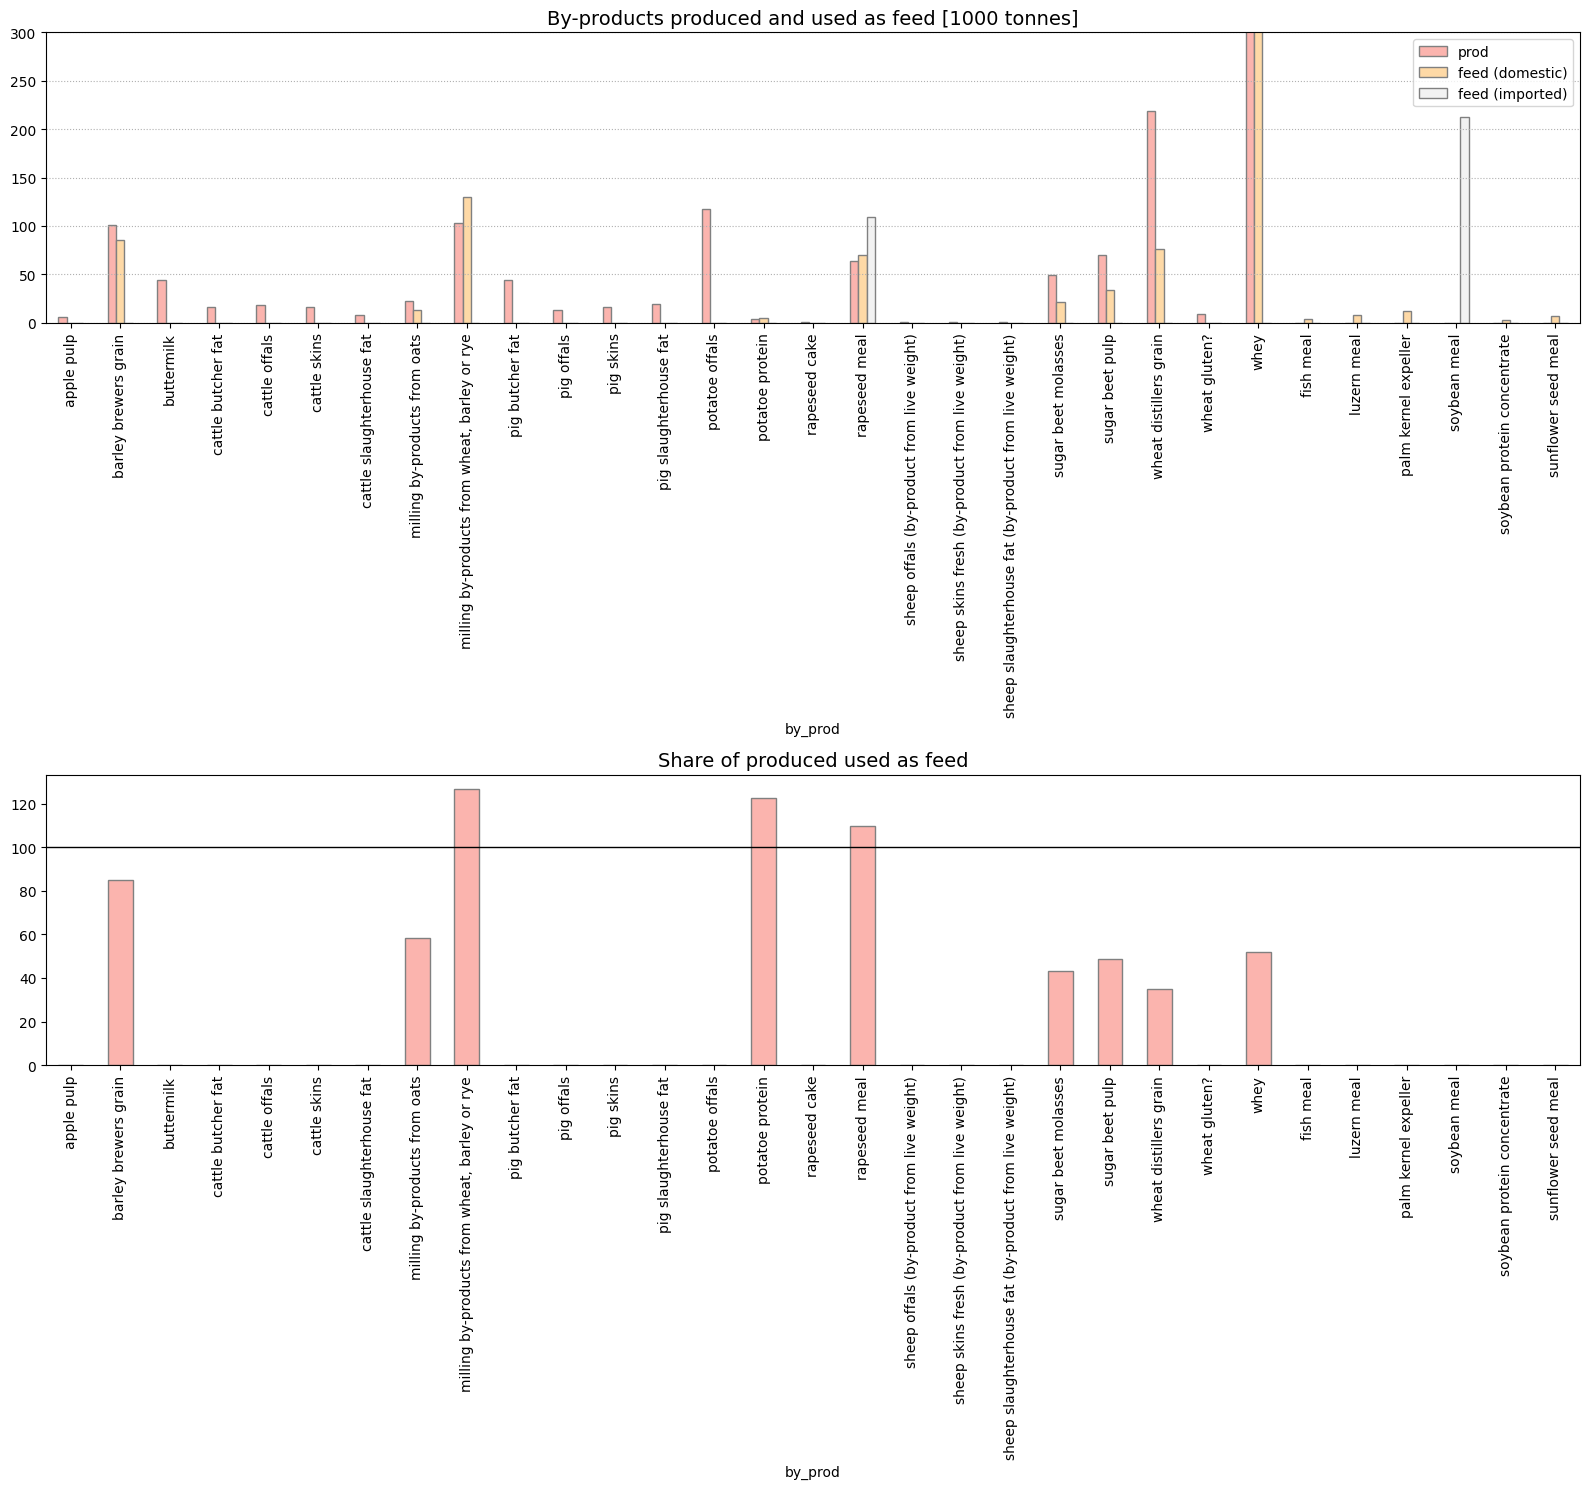

In [19]:
plot_data = pd.concat([
        
    session.get_attr('D', 'by_products', 'by_prod')
    .loc[(scn,year)]
    .rename('prod'),
    
    (session.get_attr('A', 'feed.by_product_demand', ['by_prod','origin'])
    .loc[(scn,year)]
    .drop(index='regional',level='origin', errors='ignore')
    .unstack()
    .rename({'domestic':'feed (domestic)','imported':'feed (imported)'}, axis=1))
    
], axis=1)/1000000
plot_data['% domestic used'] = plot_data['feed (domestic)']/plot_data['prod']*100

plot_data = plot_data.fillna(0)

fig, axs = plt.subplots(2,1, figsize=(16,15))

ax=axs[0]
plot_data.loc[:,['prod','feed (domestic)','feed (imported)']].plot(**bar_style, ax=ax, )

ax.set_title('By-products produced and used as feed [1000 tonnes]', size=14)
ax.set_yticks(range(0,int(plot_data.max().max()),50), minor=True)
ax.grid('on', linestyle=':', which='both', axis='y')
ax.set_ylim(0,300)

ax=axs[1]
plot_data.loc[:,'% domestic used'].plot(**bar_style, ax=ax)
ax.axhline(y=100, c='black', lw=1)
ax.set_title('Share of produced used as feed', size=14)

plt.tight_layout()
plt.show()

In [20]:
print('Unit: 1000 tonnes')
plot_data.style \
.format(precision=1, thousands=" ", decimal=".")

Unit: 1000 tonnes


,prod,feed (domestic),feed (imported),% domestic used
by_prod,,,,
apple pulp,5.5,0.0,0.0,0.0
barley brewers grain,101.2,85.8,0.0,84.7
buttermilk,44.0,0.0,0.0,0.0
cattle butcher fat,16.4,0.0,0.0,0.0
cattle offals,18.4,0.0,0.0,0.0
cattle skins,15.7,0.0,0.0,0.0
cattle slaughterhouse fat,7.9,0.0,0.0,0.0
milling by-products from oats,22.0,12.9,0.0,58.4
"milling by-products from wheat, barley or rye",102.7,130.3,0.0,126.8


In [21]:
table_data = (
    session.get_attr('AnimalHerd', 'feed.by_product_demand', ['by_prod','species','origin']).loc[(scn,year)]
    .drop('regional',level='origin', errors='ignore')
    .unstack(['species','origin'], fill_value=0)
    /1000
)
table_data[('total','')] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes


species,pigs,cattle,horses,sheep,poultry,cattle,pigs,poultry,sheep,total
origin,domestic,domestic,domestic,domestic,domestic,imported,imported,imported,imported,
by_prod,,,,,,,,,,
barley brewers grain,85 761,0,0,0,0,0,0,0,0,85 761
fish meal,3 441,0,0,0,0,0,0,0,0,3 441
luzern meal,0,3 569,4 491,85,0,0,0,0,0,8 146
milling by-products from oats,0,5 355,7 353,148,0,0,0,0,0,12 856
"milling by-products from wheat, barley or rye",74 540,42 007,9 154,635,3 914,0,0,0,0,130 250
palm kernel expeller,227,11 605,0,11,0,0,0,0,0,11 842
potatoe protein,1 319,122,26,0,3 664,0,0,0,0,5 131
rapeseed meal,11 499,51 265,0,258,6 936,80 183,17 985,10 849,403,179 378


In [22]:
sel = 'cattle'

table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['species', 'breed', 'animal', 'feed']).loc[(scn,year)]
    .xs(sel)
    .unstack(['breed','animal'], fill_value=0)
    /
    session.get_attr('AnimalHerd', 'heads', ['species', 'breed', 'animal']).loc[(scn,year)]
    .xs(sel)
)

table_data.loc['total',:] = table_data.sum()

print('Unit: kg DM/head')
table_data.style \
.format(precision=1, thousands=" ", decimal=".",)

Unit: kg DM/head


In [23]:
table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['feed', 'species']).loc[(scn,year)]
    .unstack()
).fillna(0)/1000
table_data['total'] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes DM')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes DM


species,cattle,horses,pigs,poultry,sheep,total
feed,,,,,,
barley,336 545,999,223 818,11 263,1 205,573 830
barley brewers grain,0,0,21 012,0,0,21 012
broad beans,13 851,0,46 582,0,65,60 499
fish meal,0,0,3 104,0,0,3 104
grazing,993 933,281 824,0,0,108 494,1 384 251
hay,0,738 690,0,0,0,738 690
"ley silage, 1st cut",1 384 749,0,0,0,30 031,1 414 780
"ley silage, regrowth",939 921,0,0,0,60 062,999 983
linseed,65,0,202,0,2,269


In [24]:
table_data = session.get_attr('AnimalHerd', 'feed.demand', ['feed', 'species', 'breed', 'animal']).loc[(scn,year)]
table_data = (
    table_data
    .loc['grazing']
    /
    table_data
    .loc[['grazing', 'hay', 'ley silage, 1st cut', 'ley silage, regrowth', 'maize silage', 'other silage', 'straw']]
    .groupby(['species','breed','animal'])
    .sum()
    * 100
).fillna(0)

table_data.rename('% grazing').to_frame().style \
.format(precision=1, decimal=".",)

### Forage and pasture use per livestock system

In [25]:
plot_data

,prod,feed (domestic),feed (imported),% domestic used
by_prod,,,,
apple pulp,5.520444,0.000000,0.000000,0.000000
barley brewers grain,101.217551,85.761287,0.000000,84.729660
buttermilk,43.989177,0.000000,0.000000,0.000000
cattle butcher fat,16.373529,0.000000,0.000000,0.000000
cattle offals,18.367741,0.000000,0.000000,0.000000
cattle skins,15.743778,0.000000,0.000000,0.000000
cattle slaughterhouse fat,7.871889,0.000000,0.000000,0.000000
milling by-products from oats,22.015102,12.855645,0.000000,58.394663
"milling by-products from wheat, barley or rye",102.695406,130.250233,0.000000,126.831607


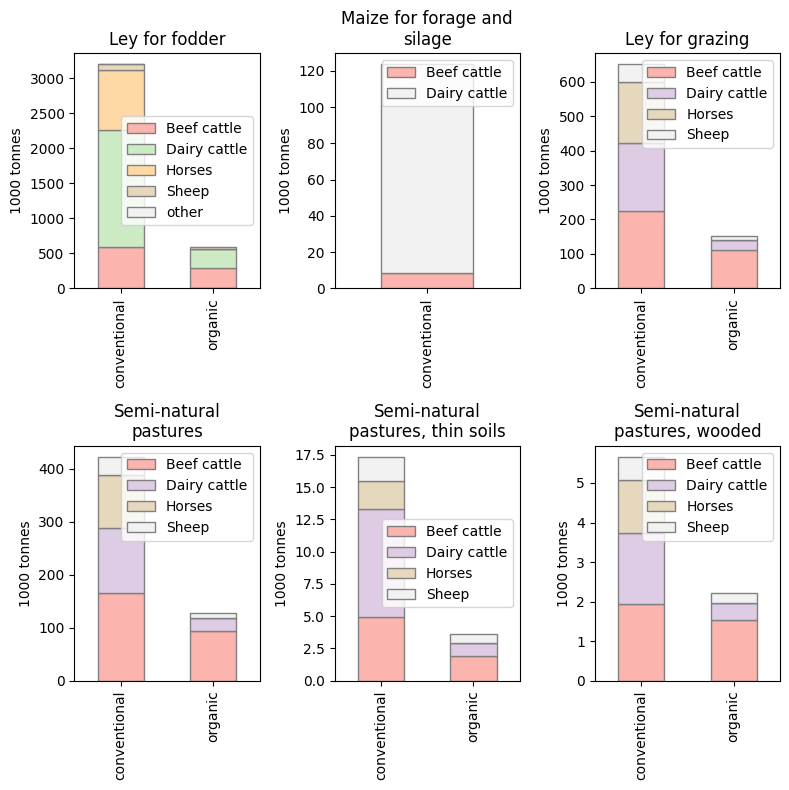

In [26]:
from textwrap import wrap
fig, axs = plt.subplots(2,3, figsize=(8,8))

for ax, cr in zip(
    axs.flatten(),
    ['Ley for fodder', 'Maize for forage and silage', 'Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']
):
    plot_data = (
        session.get_attr('c','production_per_use')
        .loc[(scn,year),cr]
        .groupby(['prod_system','demand'])
        .sum()
        .replace({0:np.nan})
        .dropna()
        .unstack()
    )/1000000
    plot_data.columns = ['Dairy cattle' if 'cattle, dairy' in c else 'Beef cattle' if 'cattle, beef' in c else 'Horses' if 'horses' in c else 'Sheep' if 'sheep' in c else 'other' for c in plot_data.columns]
    plot_data = plot_data.T.groupby(level=0).sum().T
    
    plot_data.plot(**bar_style, stacked=True, ax=ax)
    ax.set_title('\n'.join(wrap(cr, 20)))
    ax.set_ylabel('1000 tonnes')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Crop areas (deviation from x0)

#### Total crop areas

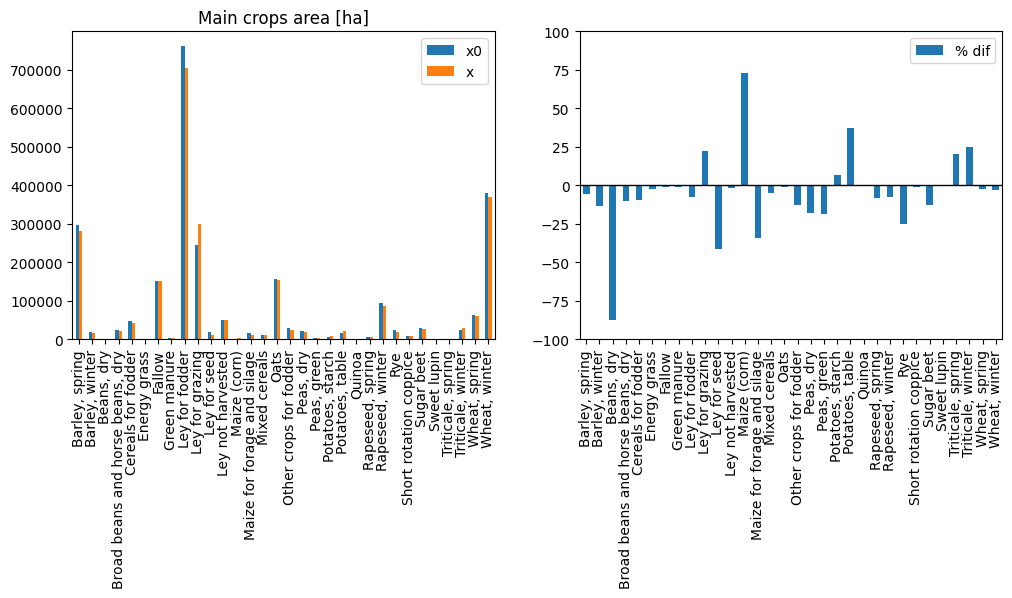

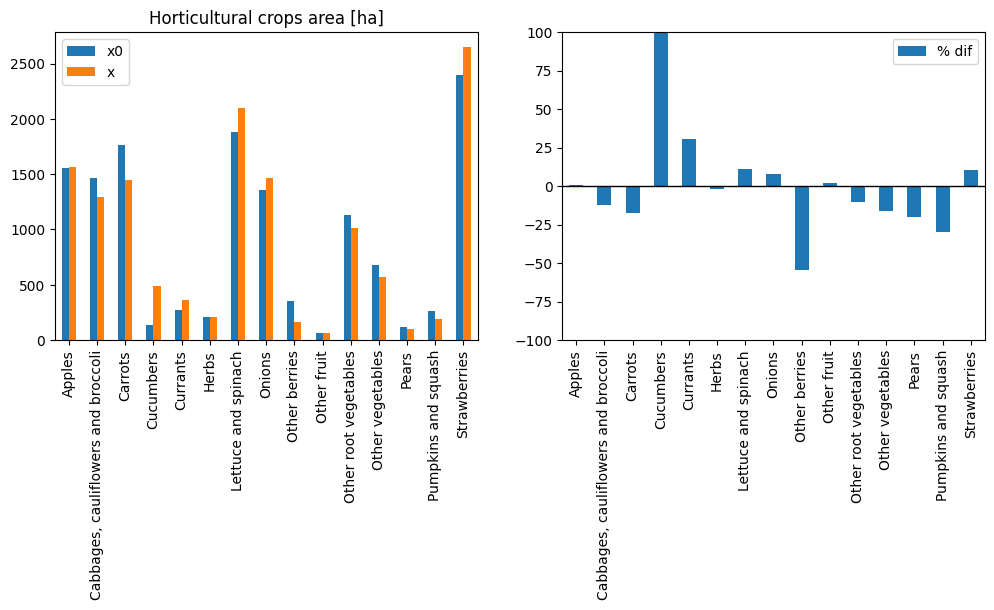

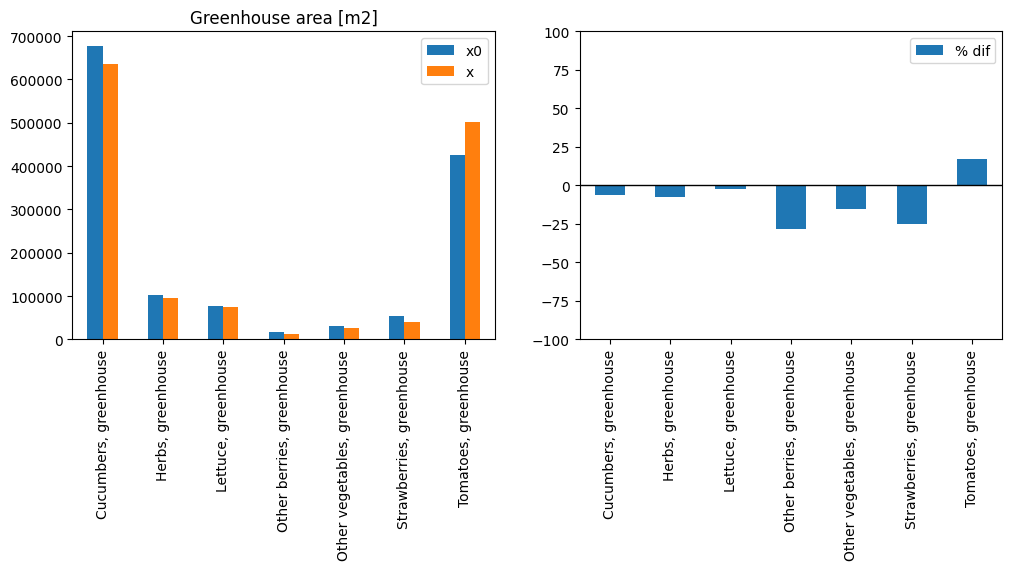

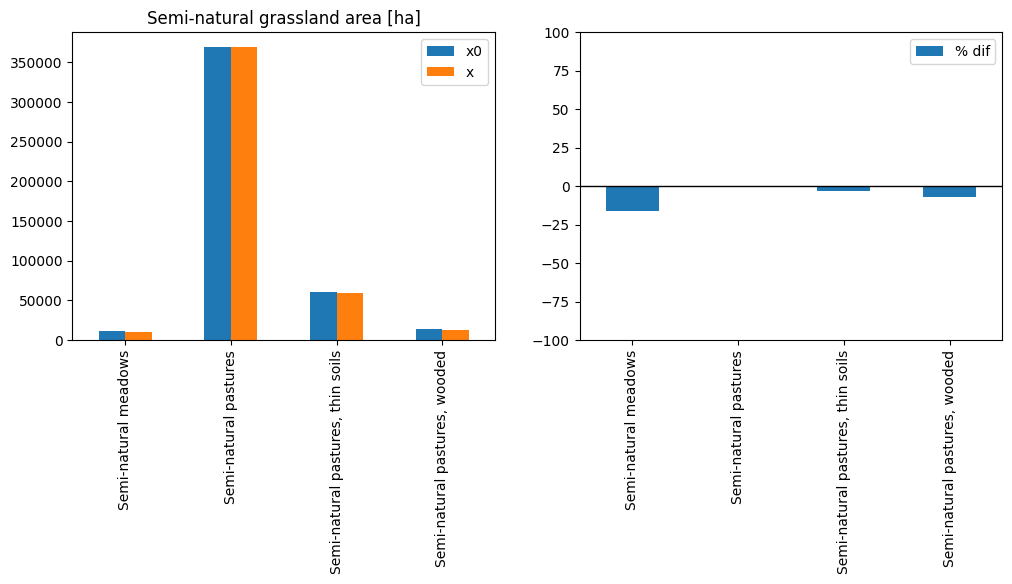

In [27]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['dif'] = plot_data.apply(lambda x:(x['x']-x['x0']), axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

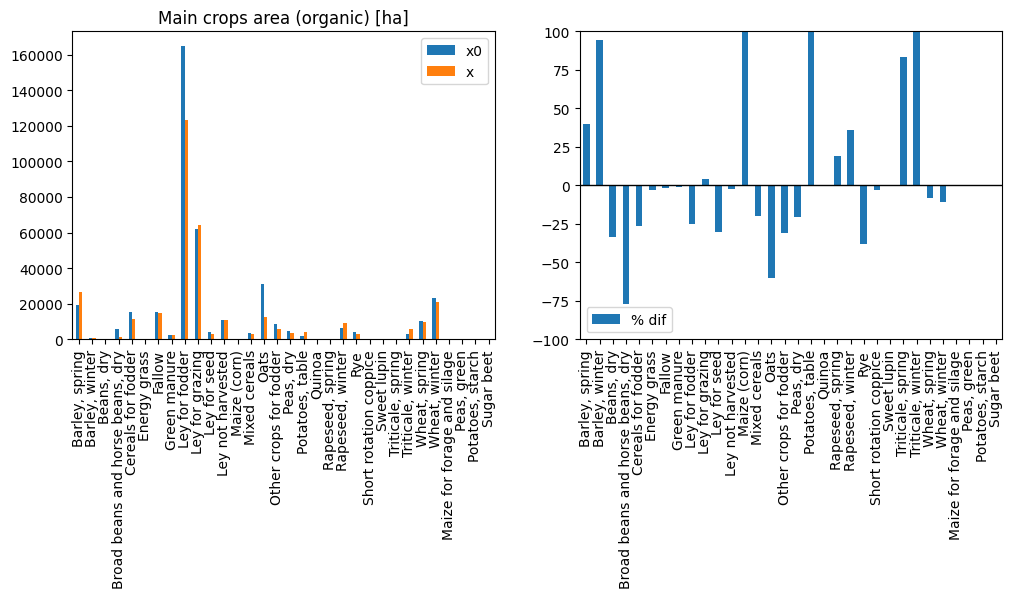

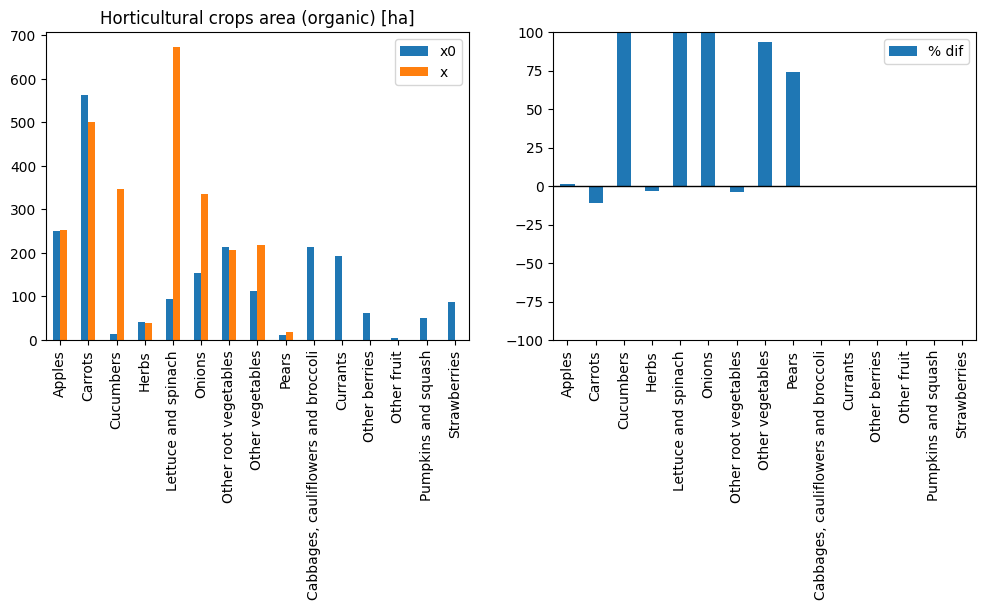

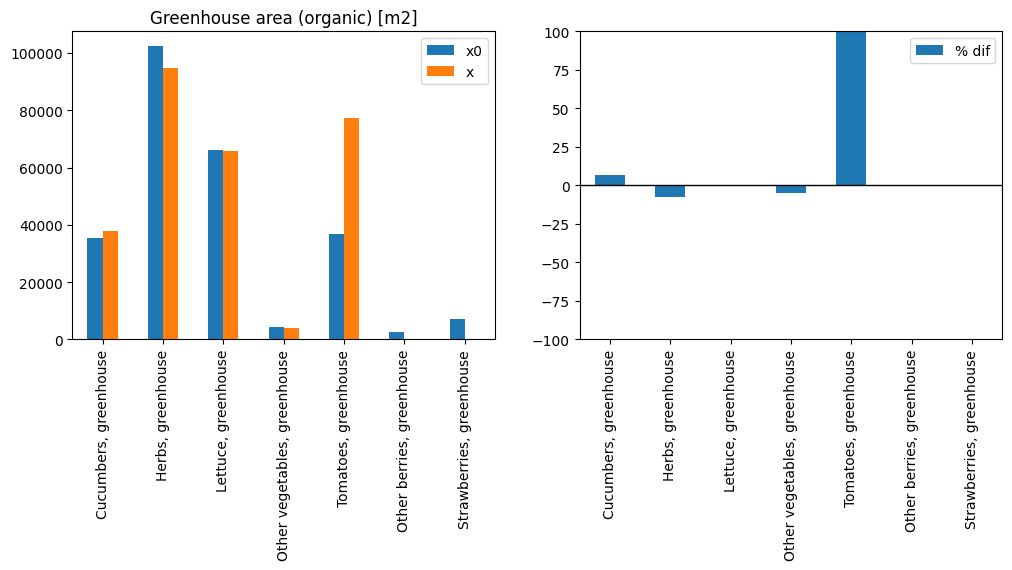

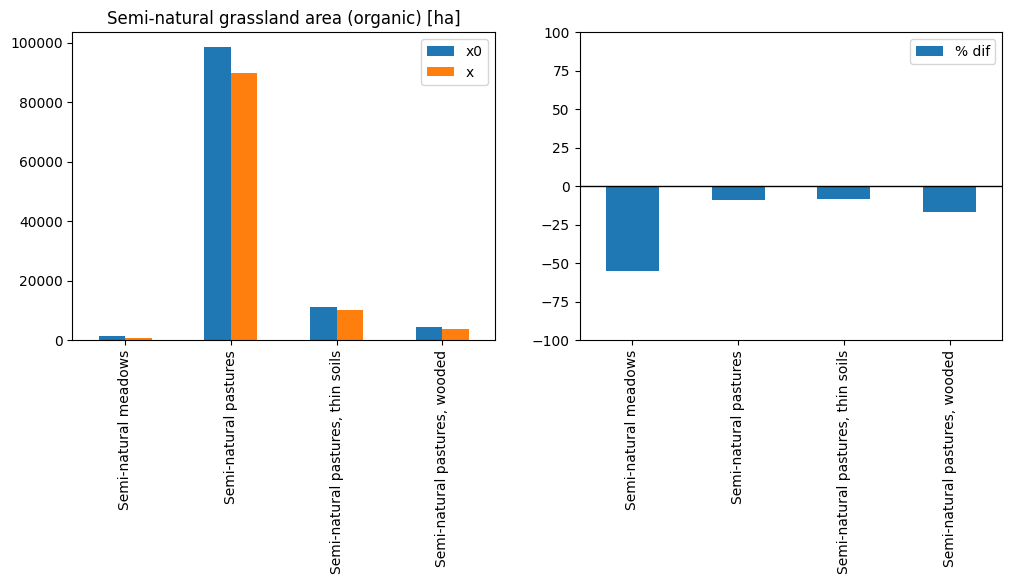

In [28]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop','prod_system']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop','prod_system']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100 if x['x0']>0 else np.nan, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area (organic) [ha]' : cr,
    'Horticultural crops area (organic) [ha]' : hr,
    'Greenhouse area (organic) [m2]' : gh,
    'Semi-natural grassland area (organic) [ha]' : sng
}

plot_data = plot_data.xs('organic', level='prod_system')
for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

#### Crop categories and some main crops per region

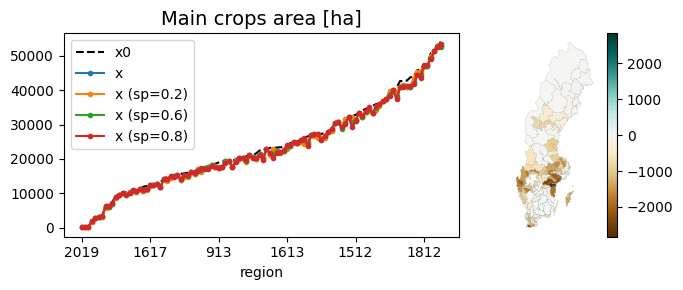

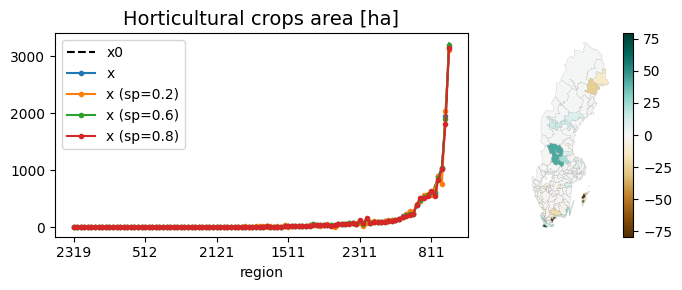

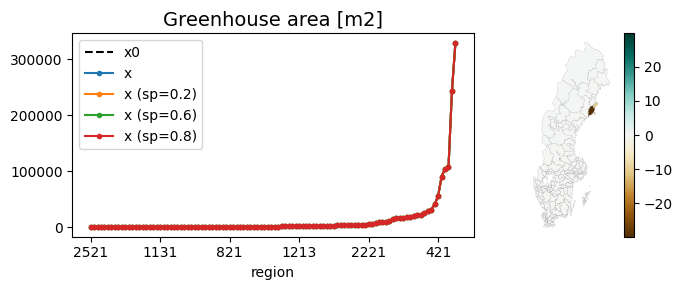

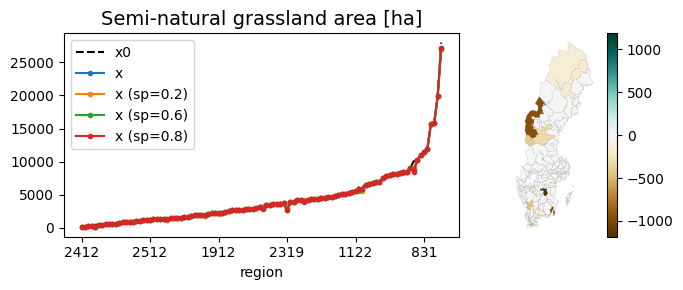

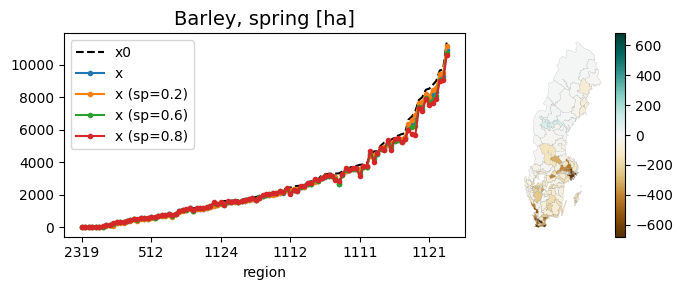

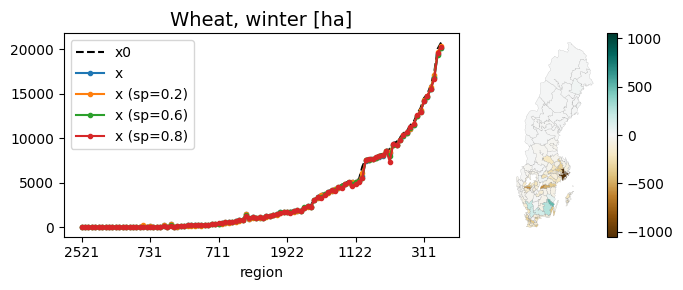

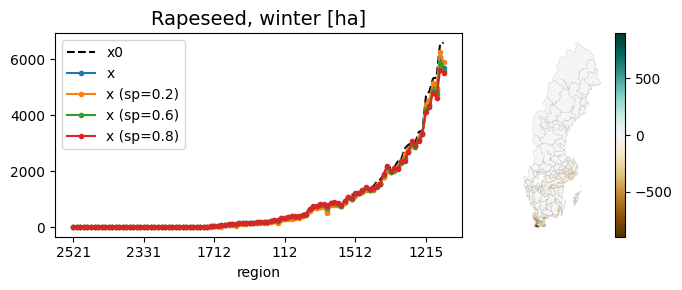

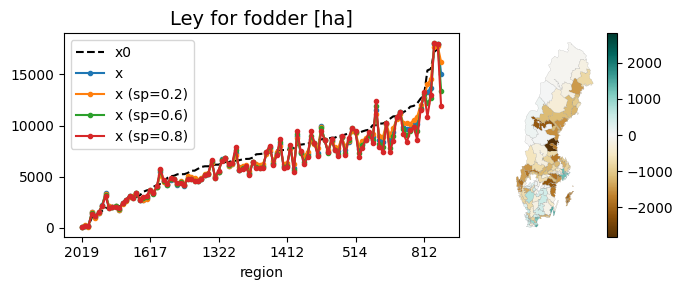

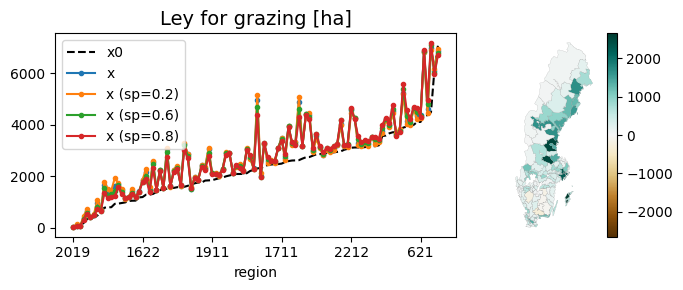

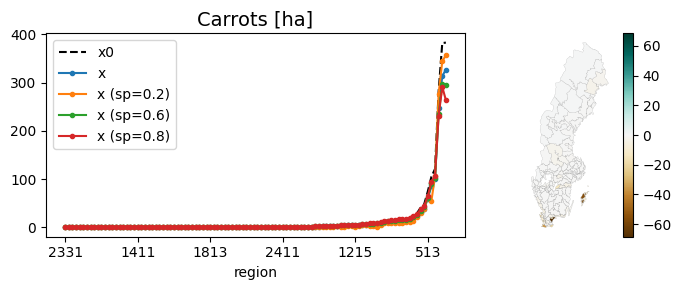

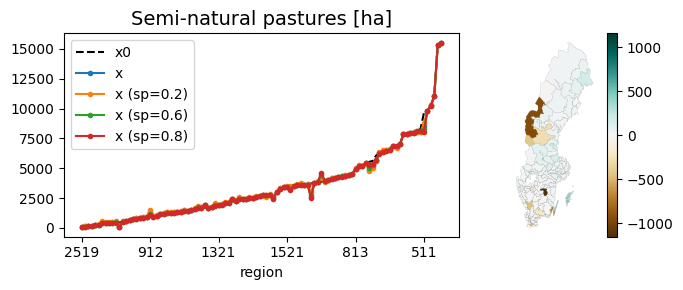

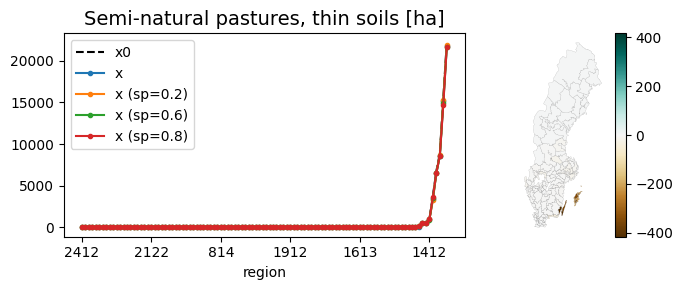

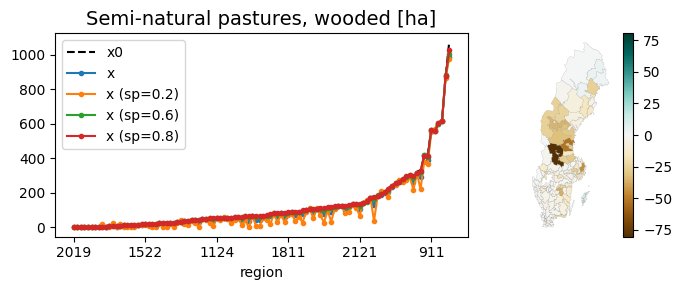

In [29]:
plot_data_ = (
    pd.concat([
        session.get_attr('C','area',['crop','region']).droplevel('year').rename(lambda x: x.replace('base year', 'x')).T,
        session.get_attr('R','x0_crops',['crop','region']).loc[(scn,year)].rename('x0')
    ], axis=1)
)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:

    # Crops
    plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in session.scenarios('has output')], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(p, size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Some main crops
crps = ['Barley, spring','Wheat, winter','Rapeseed, winter','Ley for fodder','Ley for grazing','Carrots','Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']
for crp in crps:
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in session.scenarios('has output')], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(crp+' [ha]', size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

### Animal numbers (deviations from x0)

#### Total animal numbers

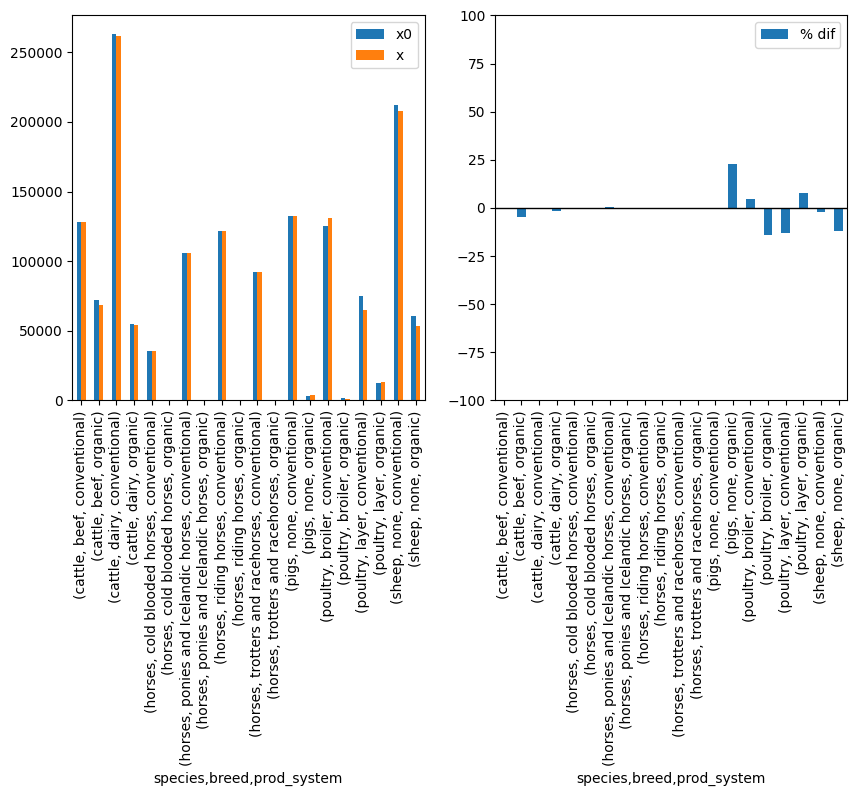

In [30]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        session.get_attr('A','heads',['region','species','breed','prod_system','animal'])
        .droplevel('year')
        .rename(lambda x: x.replace('base year','x'))
        .T
        .loc[idx[:,:,:,:,[
                'cows',
                'sows','gilts',
                'broodmares','low-performing horses','medium-performing horses','young horses',
                'broilers',
                'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
                'ewes','rams'
            ]],:]
        .groupby(['region','species','breed','prod_system'])
        .sum()
        ,
        session.get_attr('R','x0_animals',['region','species','breed','prod_system']).loc[(scn,year)]
        .rename('x0')
    ], axis=1)
)

# Adjust poultry to 100 heads
plot_data_ = \
plot_data_.mul(np.where(plot_data_.index.get_level_values('species')=='poultry',1/100,1), axis=0)

plot_data = plot_data_.groupby(['species','breed','prod_system']).sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(10,5))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

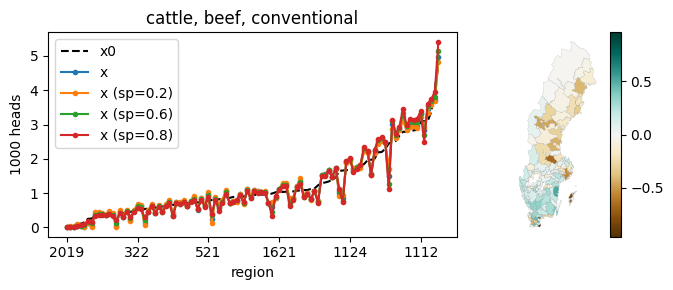

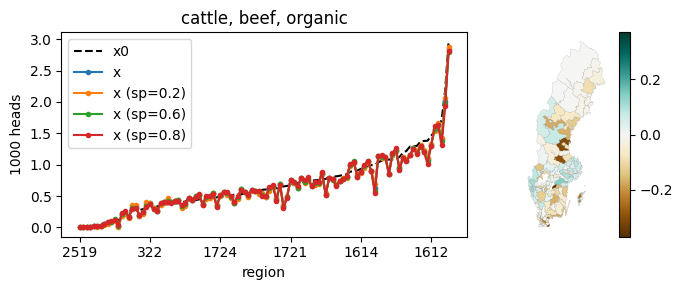

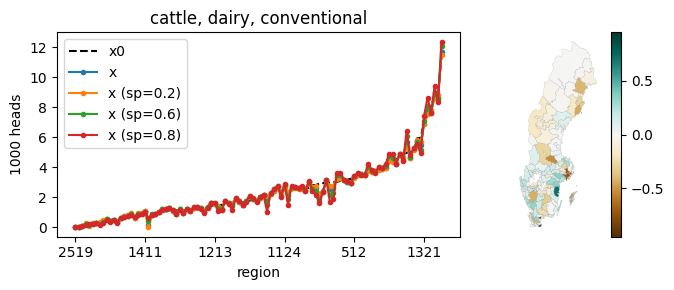

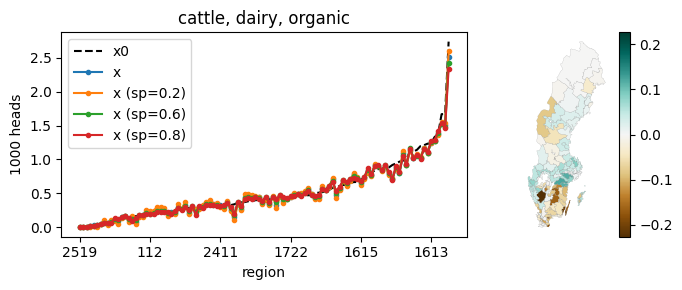

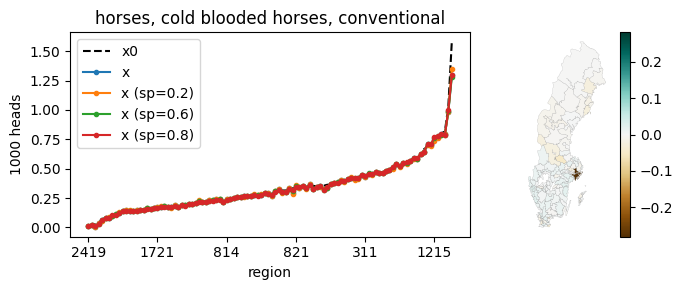

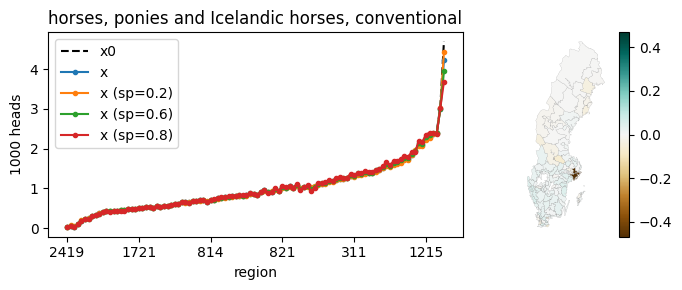

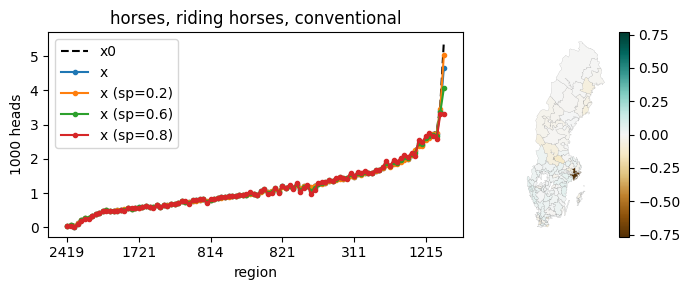

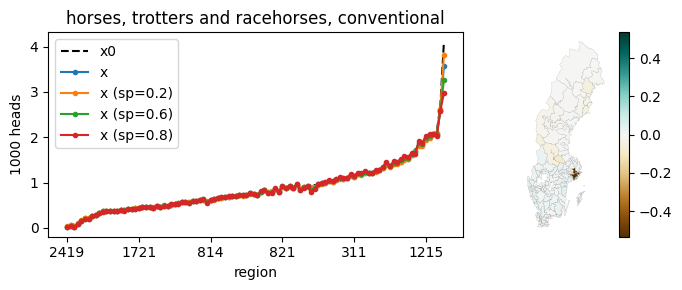

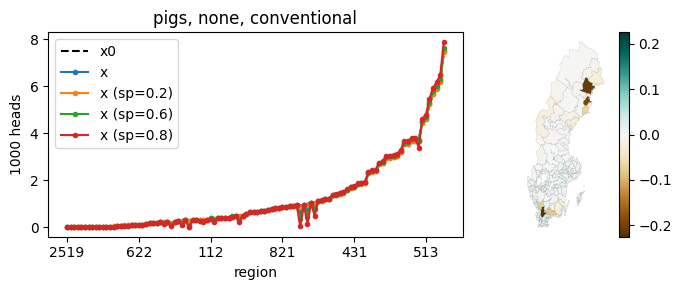

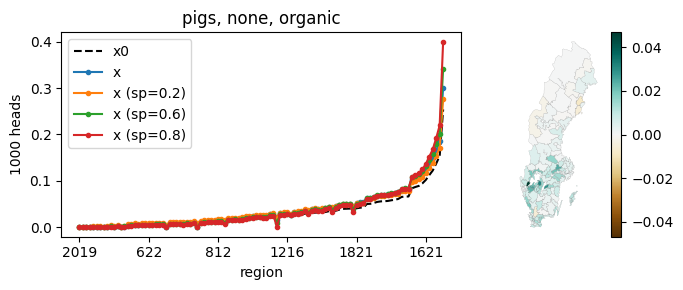

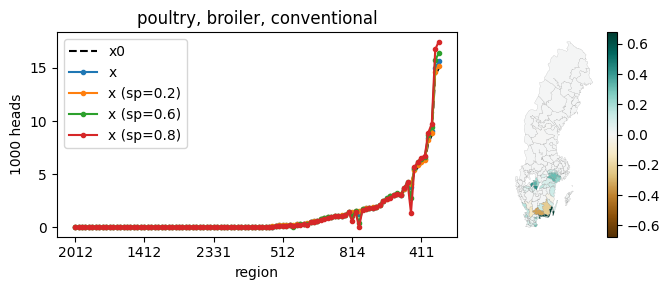

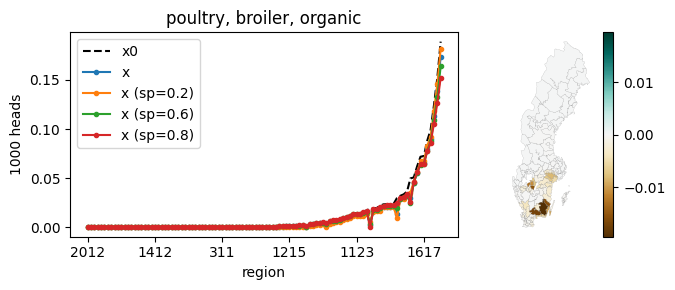

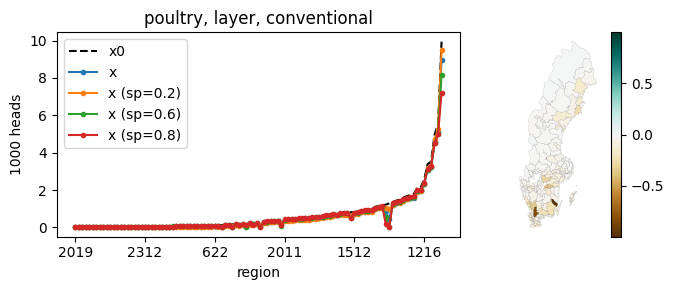

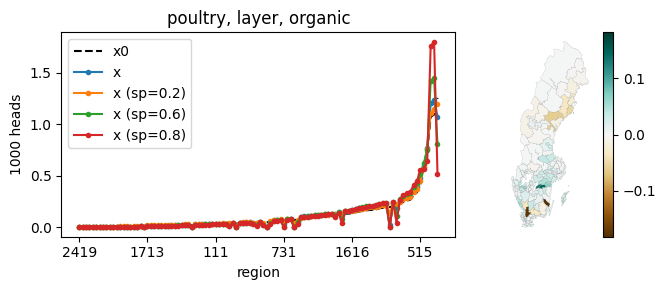

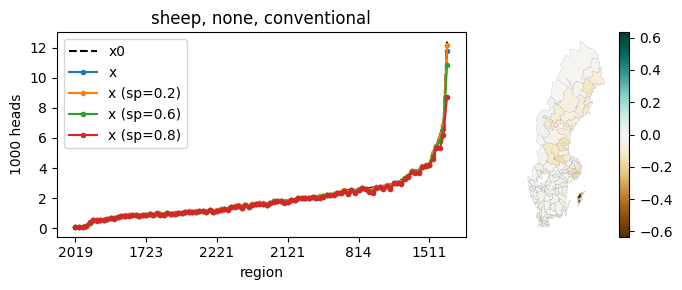

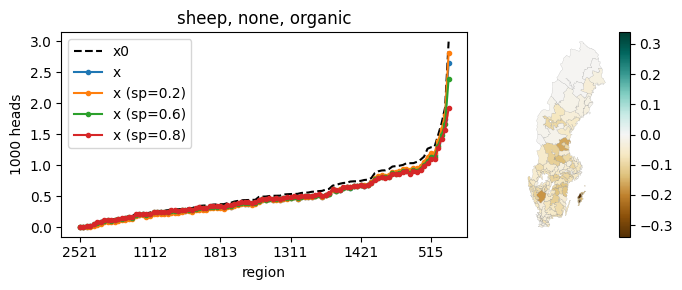

In [31]:
for idx in plot_data_.index.droplevel('region').unique():
    
    if 'horses' in idx and 'organic' in idx:
        continue
        
    plot_data = plot_data_.xs(idx, level=('species','breed','prod_system')).copy()/1000
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in session.scenarios('has output')], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(', '.join(idx))
    ax.set_ylabel('1000 heads')

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

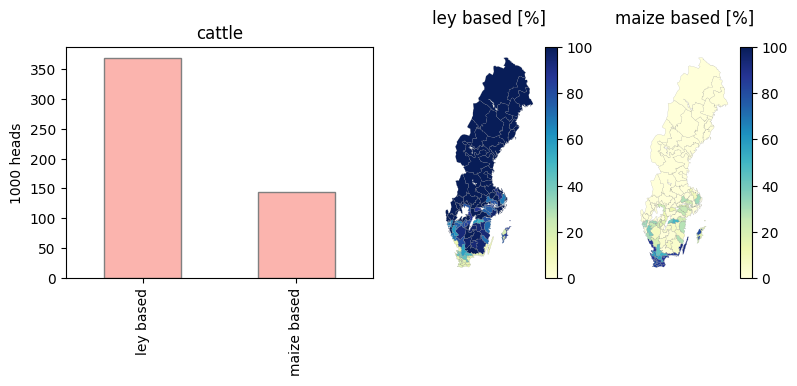

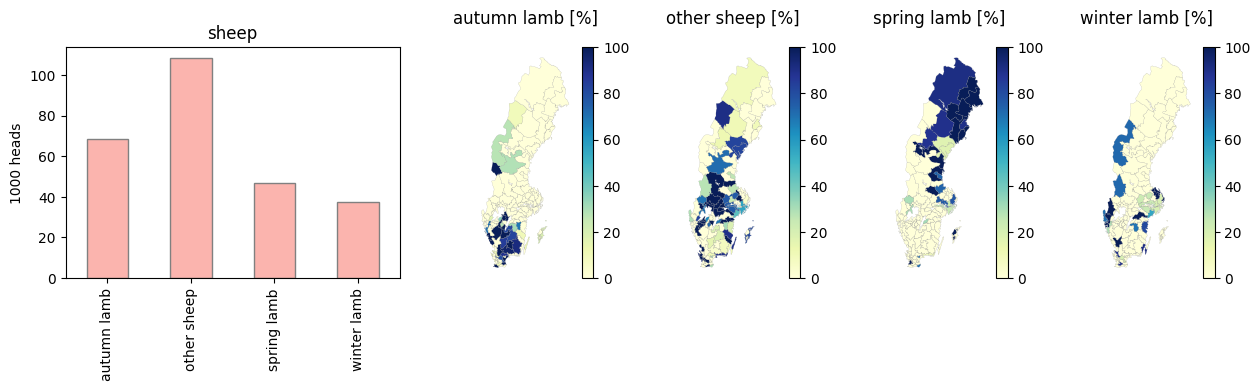

In [32]:
idx = pd.IndexSlice
plot_data = (
    session.get_attr('A','heads',['species','sub_system','region','animal']).loc[(scn,year)]
    .loc[idx[:,:,:,[
            'cows',
            'sows','gilts',
            'broodmares','low-performing horses','medium-performing horses','young horses',
            'broilers',
            'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
            'ewes','rams'
        ]]]
    .groupby(['species','sub_system','region'])
    .sum()
)/1000


for sp in plot_data.index.get_level_values('species').unique():
    plot_data_ = plot_data.xs(sp)
    sss = plot_data_.index.get_level_values('sub_system').unique()
    n_ss = len(sss)
    if n_ss>1:
        fig, axs = plt.subplots(1, 1+n_ss, figsize=(3+3*n_ss,3), gridspec_kw={'width_ratios': [2] + [1]*n_ss})
        ax=axs[0]
        plot_data_.groupby('sub_system').sum().plot(**bar_style, ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('1000 heads')
        ax.set_title(sp)
        
        map_data = plot_data_.groupby('region').transform(lambda x: x/x.sum() * 100)
        for ax,ss in zip(axs[1::],sss):
            plot.map_from_series(
                map_data.xs(ss),
                ax=ax,
                vmin=0,
                vmax=100,
                **map_style
            )
            ax.set_title(ss + ' [%]')
            ax.axis('off')
            
        plt.show()

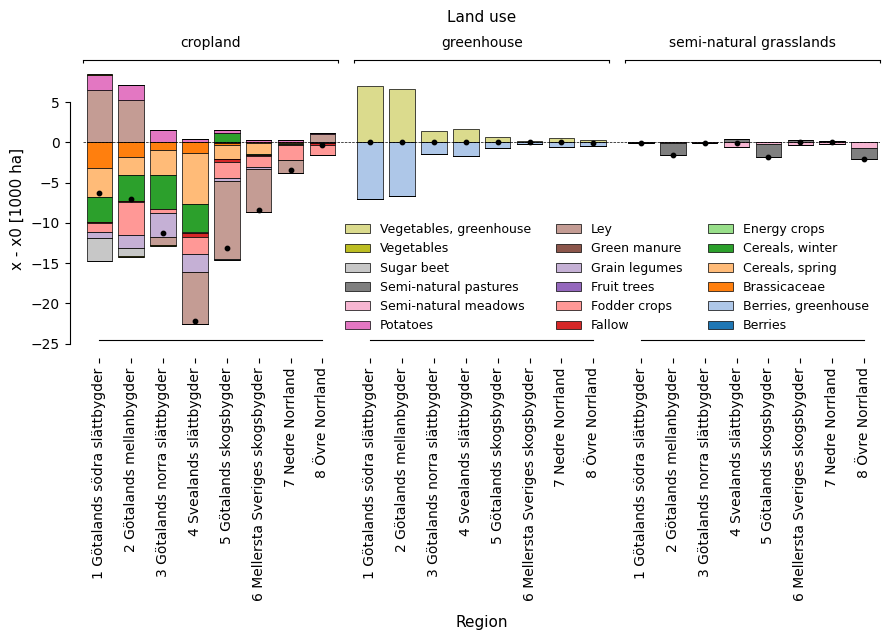

In [33]:
fig = plt.figure(figsize=(9,6.5))
data = (
    (session.get_attr('cr','area',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0] -
    session.get_attr('r','x0_crops',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0]) / 1000
).unstack('crop_group')
ax = plot.bar(data, stacked=True, group_levels='land_use', sort_xlabels=False, sort_groups=False, cmap='tab20', grouptitle='Land use', xlabel='Region', ylabel='x - x0 [1000 ha]')

plt.tight_layout()
plt.show()

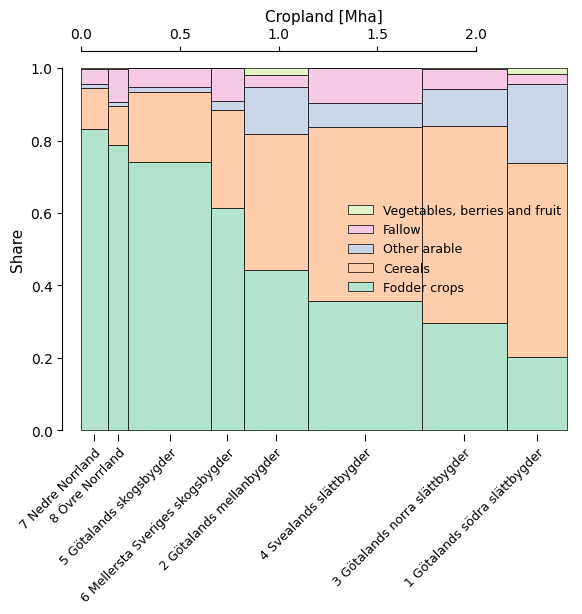

In [34]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'],'region':'po8'}).iloc[0].loc['cropland'].unstack('crop_group2') / 1000000
ax = plot.marimekko(data, xlabel='Cropland [Mha]', ylabel='Share', cmap='Pastel2')
plt.show()

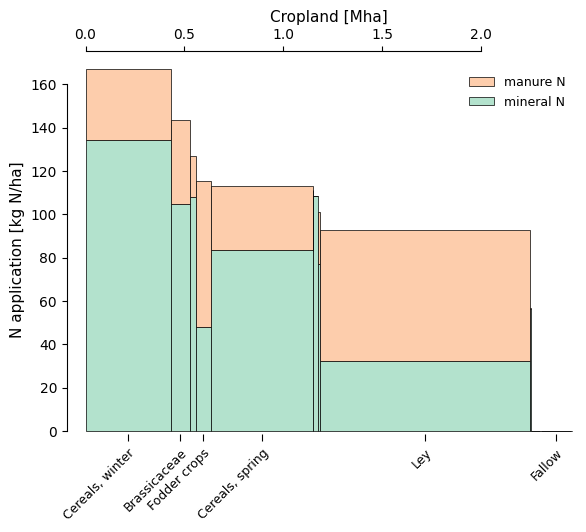

In [35]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral N'),
    session.get_attr('c','fertiliser.manure_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure N'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='N application [kg N/ha]', cmap='Pastel2')
plt.show()

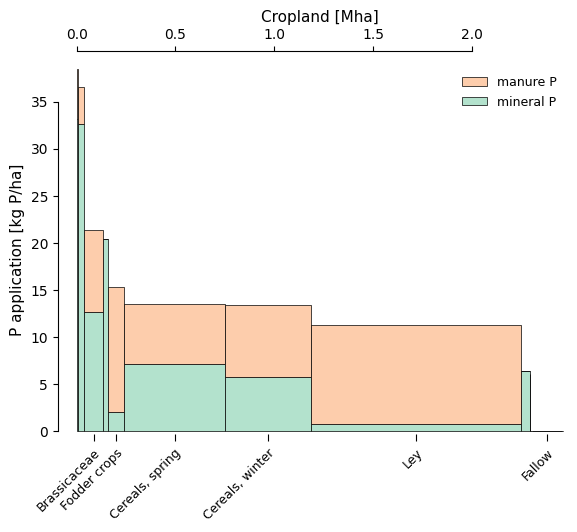

In [36]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral P'),
    session.get_attr('c','fertiliser.manure_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure P'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='P application [kg P/ha]', cmap='Pastel2', categorylabels_threshold=0.02, categorylabels_fontsize=9)
plt.show()

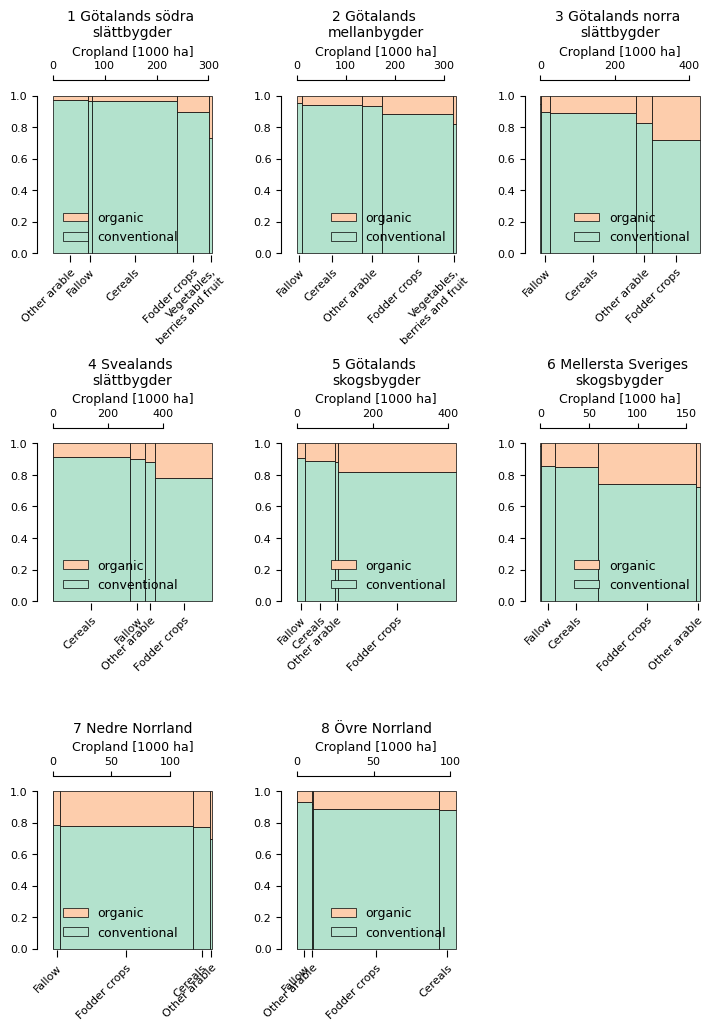

In [37]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'], 'region':'po8', 'prod_system':None}).iloc[0].loc['cropland'].unstack()/1000
fig, axs = plot.subplots(data, index='po8', plot_fn=plot.marimekko, size=(2.5,3.5), cmap='Pastel2', title_fontsize=10, categorylabels_threshold=0.01,
                         categorylabels_wrap=18, categorylabels_fontsize=8, xlabel='Cropland [1000 ha]', xlabel_fontsize=9, ticklabels_fontsize=8)
plt.tight_layout(pad=2)
plt.show()

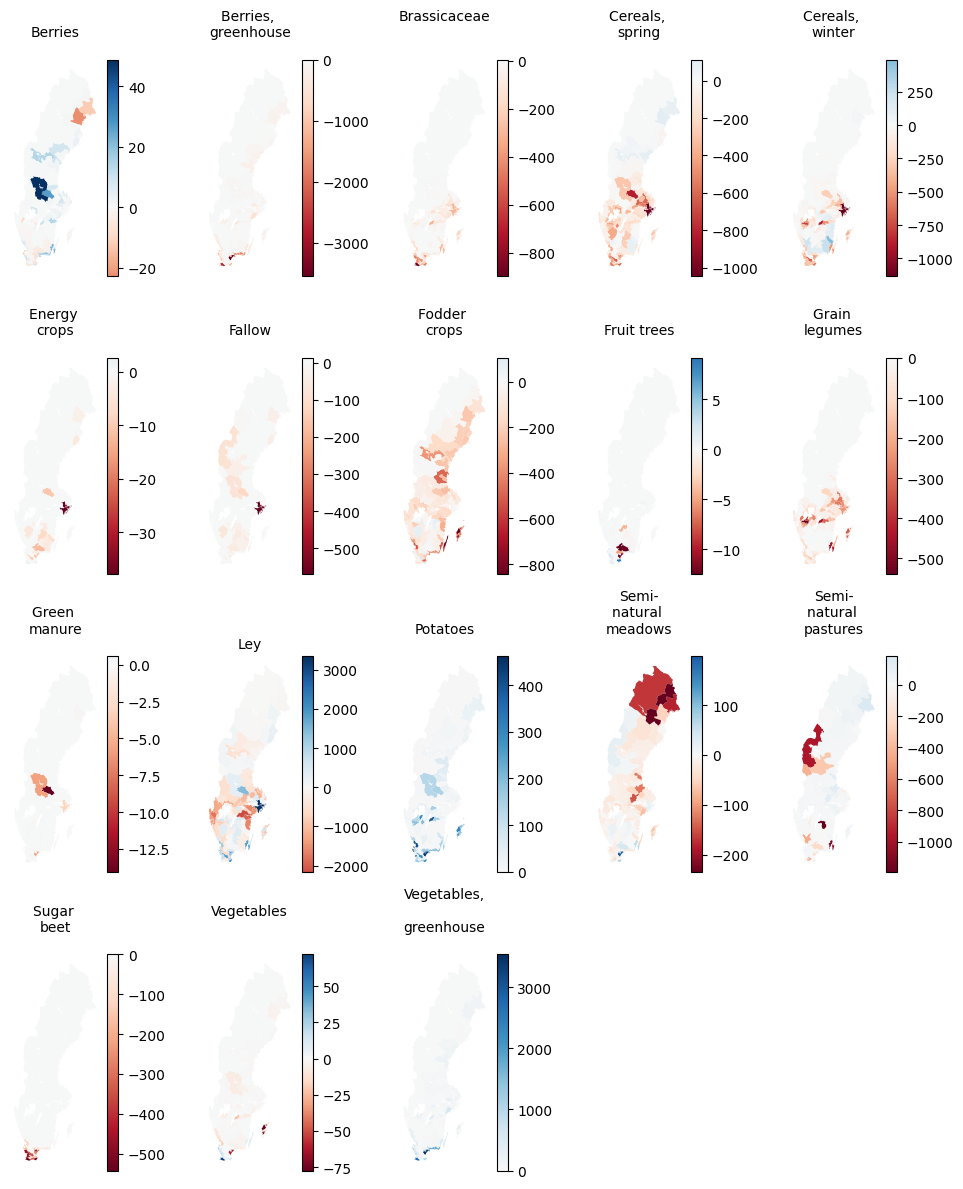

In [38]:
data = (session.get_attr('c','area',{'crop':'crop_group','region':None}) - session.get_attr('r','x0_crops',{'crop':'crop_group','region':None})).iloc[0]

fig, axs = plot.subplots(data, index='crop_group', title_fontsize=10, size=(2,3), plot_fn=plot.map_from_series, cmap='RdBu', cmap_zero_midpoint='shrink')
for ax in axs.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()